# 01. Dataset & Feature Exploratory Data Analysis (EDA)


---
## 📌 Section: 00_data_analysis.ipynb


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), ".")))

from modules.data_loader import load_config, load_ground_truth, load_experiment_json
from modules.kbrs_metrics import get_official_metrics_df
from modules.visualization import feature

In [2]:
cfg = load_config()

In [3]:
fold1_test_replays = [275, 1725, 3613, 4520, 4664]

In [4]:
gt_df = load_ground_truth(cfg["data"]["label_dst_dir"], fold1_test_replays, "all_correct")

In [5]:
# # IoU 계산 함수 정의 (입력 포맷: [x, y, w, h])
# def calculate_iou(boxA, boxB):
#     xA = max(boxA[0], boxB[0])
#     yA = max(boxA[1], boxB[1])
#     xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
#     yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
    
#     interArea = max(0, xB - xA) * max(0, yB - yA)
#     boxAArea = boxA[2] * boxA[3]
#     boxBArea = boxB[2] * boxB[3]
#     unionArea = boxAArea + boxBArea - interArea
    
#     return interArea / unionArea if unionArea > 0 else 0

In [6]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm  # Jupyter Notebook용 tqdm

def calculate_temporal_alignment_batch(input_df, window_size=12, majority_threshold=3):
    """
    데이터프레임 전체를 입력받아 시간적 관대함(Temporal Window)이 적용된 
    temporal_alignment_score를 고속으로 계산합니다.
    """
    df = input_df.copy()
    
    # 1. 사전 전처리: 원본 데이터에 annotator_id 나 좌표 컬럼이 없을 경우를 대비해 생성
    if 'annotator_id' not in df.columns:
        df['annotator_id'] = df.groupby(['replay', 'image_id']).cumcount() + 1
        
    if 'x' not in df.columns:
        df[['x', 'y', 'w', 'h']] = pd.DataFrame(df['bbox'].tolist(), index=df.index)
        
    results = []
    
    # 리플레이별로 그룹화
    replays = df.groupby('replay')
    
    for replay_name, replay_df in replays:
        # 프레임(image_id) 순으로 정렬
        replay_df = replay_df.sort_values('image_id')
        
        # 캔버스 크기를 고정하기 위해 해당 리플레이의 최대/최소 좌표 추출 (정수형 강제)
        min_x = int(replay_df['x'].min())
        min_y = int(replay_df['y'].min())
        max_x = int((replay_df['x'] + replay_df['w']).max())
        max_y = int((replay_df['y'] + replay_df['h']).max())
        
        width = max_x - min_x
        height = max_y - min_y
        
        if width <= 0 or height <= 0:
            continue
            
        # 해당 리플레이에 존재하는 모든 유니크한 프레임 번호
        all_frames = sorted(replay_df['image_id'].unique())
        
        # 2. tqdm 적용: 리플레이별로 프레임 탐색 진행률을 표시합니다.
        for target_frame in tqdm(all_frames, desc=f"Replay [{replay_name}] Temporal Window"):
            
            # 윈도우(앞뒤 관대함 구간) 내의 데이터 추출
            window_mask = (replay_df['image_id'] >= target_frame - window_size) & \
                          (replay_df['image_id'] <= target_frame + window_size)
            window_df = replay_df[window_mask]
            
            # 윈도우 내 개인별 누적 시야 마스크 생성
            annotator_masks = {annot_id: np.zeros((height, width), dtype=np.uint8) 
                               for annot_id in window_df['annotator_id'].unique()}
            
            for _, row in window_df.iterrows():
                # 좌표를 안전하게 정수(int)로 변환
                x_start = int(row['x'] - min_x)
                x_end = int(row['x'] + row['w'] - min_x)
                y_start = int(row['y'] - min_y)
                y_end = int(row['y'] + row['h'] - min_y)
                
                # 시야 누적 (1로 덮어쓰기)
                annotator_masks[row['annotator_id']][y_start:y_end, x_start:x_end] = 1
                
            # 시간적 합의(Temporal Consensus) 히트맵 도출
            if not annotator_masks:
                continue
                
            temporal_canvas = sum(annotator_masks.values())
            hotspot_mask = (temporal_canvas >= majority_threshold)
            
            # 현재 프레임(target_frame)의 작업자별 점수 계산
            target_df = replay_df[replay_df['image_id'] == target_frame]
            
            for _, row in target_df.iterrows():
                x_start = int(row['x'] - min_x)
                x_end = int(row['x'] + row['w'] - min_x)
                y_start = int(row['y'] - min_y)
                y_end = int(row['y'] + row['h'] - min_y)
                
                my_view_in_hotspot = hotspot_mask[y_start:y_end, x_start:x_end]
                my_area = row['w'] * row['h']
                
                overlap_area = np.sum(my_view_in_hotspot)
                alignment_score = overlap_area / my_area if my_area > 0 else 0
                
                results.append({
                    'id': row['id'],  # 원본 데이터와의 병합을 위한 고유 ID
                    'replay': replay_name,
                    'image_id': target_frame,
                    'annotator_id': row['annotator_id'],
                    'temporal_alignment_score': round(alignment_score, 4)
                })

    # 전체 결과를 DataFrame으로 반환
    return pd.DataFrame(results)

In [9]:
def analyze_result(results_df):
    desc_df = results_df[["replay", "annotator_id", "temporal_alignment_score"]].groupby(["replay", "annotator_id"]).describe()

    # 다중 인덱스('alignment_score') 제거 및 인덱스 리셋
    desc_df.columns = desc_df.columns.droplevel(0) 
    desc_df = desc_df.reset_index()

    
    # 관전자별로 각 통계치의 평균
    annotator_overall = desc_df.groupby("annotator_id").mean(numeric_only=True)
    
    overall_summary = desc_df.drop(columns=['replay', 'annotator_id']).describe()

    return desc_df, annotator_overall, overall_summary

In [19]:
instant_m3_results_df = calculate_temporal_alignment_batch(gt_df, window_size=0, majority_threshold=3)
instant_m3_desc_df, instant_m3_annotator_overall, instant_m3_overall_summary = analyze_result(instant_m3_results_df)

Replay [1725.rep] Temporal Window:   0%|          | 0/18188 [00:00<?, ?it/s]

Replay [275.rep] Temporal Window:   0%|          | 0/66688 [00:00<?, ?it/s]

Replay [3613.rep] Temporal Window:   0%|          | 0/19046 [00:00<?, ?it/s]

Replay [4520.rep] Temporal Window:   0%|          | 0/24103 [00:00<?, ?it/s]

Replay [4664.rep] Temporal Window:   0%|          | 0/20634 [00:00<?, ?it/s]

In [20]:
print("=== instant, majority_threshold=3 ===")
instant_m3_desc_df

=== instant, majority_threshold=3 ===


,replay,annotator_id,count,mean,std,min,25%,50%,75%,max
0,1725.rep,1,18188.0,0.315698,0.368230,0.0,0.0,0.0000,0.7000,1.0
1,1725.rep,2,18188.0,0.285858,0.365813,0.0,0.0,0.0000,0.6500,1.0
2,1725.rep,3,18188.0,0.328279,0.378491,0.0,0.0,0.0000,0.7208,1.0
3,1725.rep,4,18188.0,0.273796,0.360259,0.0,0.0,0.0000,0.6250,1.0
4,1725.rep,5,18188.0,0.306979,0.362211,0.0,0.0,0.0000,0.6708,1.0
5,275.rep,1,66688.0,0.334709,0.366683,0.0,0.0,0.1333,0.7125,1.0
6,275.rep,2,66688.0,0.271260,0.360528,0.0,0.0,0.0000,0.6417,1.0
7,275.rep,3,66688.0,0.349636,0.373143,0.0,0.0,0.1833,0.7333,1.0
8,275.rep,4,66688.0,0.290824,0.359662,0.0,0.0,0.0000,0.6667,1.0
9,275.rep,5,66688.0,0.333295,0.365935,0.0,0.0,0.1250,0.7083,1.0


In [21]:
print(" - 관전자별")
instant_m3_annotator_overall[['mean', 'std', '75%', 'max']]

 - 관전자별


,mean,std,75%,max
annotator_id,,,,
1,0.298964,0.359876,0.66918,1.0
2,0.268322,0.356874,0.62084,1.0
3,0.311874,0.369582,0.69832,1.0
4,0.271628,0.357163,0.63168,1.0
5,0.290149,0.351801,0.63582,1.0


In [22]:
print(" -  전체 데이터셋")
instant_m3_overall_summary

 -  전체 데이터셋


,count,mean,std,min,25%,50%,75%,max
count,25.00000,25.000000,25.000000,25.0,25.0,25.000000,25.000000,25.0
mean,29731.80000,0.288187,0.359059,0.0,0.0,0.017664,0.651168,1.0
std,18971.79767,0.028029,0.010829,0.0,0.0,0.049662,0.052446,0.0
min,18188.00000,0.238373,0.334932,0.0,0.0,0.000000,0.525000,1.0
25%,19046.00000,0.271260,0.352410,0.0,0.0,0.000000,0.625000,1.0
50%,20634.00000,0.285363,0.359737,0.0,0.0,0.000000,0.650000,1.0
75%,24103.00000,0.306979,0.366683,0.0,0.0,0.000000,0.700000,1.0
max,66688.00000,0.349636,0.378491,0.0,0.0,0.183300,0.733300,1.0


In [11]:
instant_m2_results_df = calculate_temporal_alignment_batch(gt_df, window_size=0, majority_threshold=2)
instant_m2_desc_df, instant_m2_annotator_overall, instant_m2_overall_summary = analyze_result(instant_m2_results_df)

Replay [1725.rep] Temporal Window:   0%|          | 0/18188 [00:00<?, ?it/s]

Replay [275.rep] Temporal Window:   0%|          | 0/66688 [00:00<?, ?it/s]

Replay [3613.rep] Temporal Window:   0%|          | 0/19046 [00:00<?, ?it/s]

Replay [4520.rep] Temporal Window:   0%|          | 0/24103 [00:00<?, ?it/s]

Replay [4664.rep] Temporal Window:   0%|          | 0/20634 [00:00<?, ?it/s]

In [17]:
print("=== instant, majority_threshold=2 ===")
instant_m2_desc_df

=== instant, majority_threshold=2 ===


,replay,annotator_id,count,mean,std,min,25%,50%,75%,max
0,1725.rep,1,18188.0,0.598712,0.397125,0.0,0.0000,0.79170,0.916700,1.0
1,1725.rep,2,18188.0,0.529011,0.409189,0.0,0.0000,0.68750,0.904200,1.0
2,1725.rep,3,18188.0,0.595407,0.405332,0.0,0.0000,0.79170,0.941700,1.0
3,1725.rep,4,18188.0,0.528713,0.406707,0.0,0.0000,0.67500,0.908300,1.0
4,1725.rep,5,18188.0,0.573932,0.397356,0.0,0.0000,0.75000,0.916700,1.0
5,275.rep,1,66688.0,0.574117,0.390610,0.0,0.0333,0.73330,0.916700,1.0
6,275.rep,2,66688.0,0.471700,0.418190,0.0,0.0000,0.54170,0.900000,1.0
7,275.rep,3,66688.0,0.620819,0.382666,0.0,0.2500,0.79170,0.941700,1.0
8,275.rep,4,66688.0,0.499775,0.412102,0.0,0.0000,0.63330,0.900000,1.0
9,275.rep,5,66688.0,0.540069,0.400839,0.0,0.0000,0.67500,0.916700,1.0


In [18]:
print(" - 관전자별")
instant_m2_annotator_overall[['mean', 'std', '75%', 'max']]

 - 관전자별


,mean,std,75%,max
annotator_id,,,,
1,0.562415,0.394887,0.914610,1.0
2,0.503612,0.409880,0.900840,1.0
3,0.588665,0.398050,0.927315,1.0
4,0.512569,0.410614,0.905820,1.0
5,0.540185,0.391156,0.891680,1.0


In [14]:
print(" -  전체 데이터셋")
instant_m2_overall_summary

 -  전체 데이터셋


,count,mean,std,min,25%,50%,75%,max
count,25.00000,25.000000,25.000000,25.0,25.000000,25.00000,25.000000,25.0
mean,29731.80000,0.541489,0.400917,0.0,0.014332,0.68859,0.908053,1.0
std,18971.79767,0.038743,0.011281,0.0,0.050548,0.06522,0.018639,0.0
min,18188.00000,0.471700,0.380153,0.0,0.000000,0.54170,0.854200,1.0
25%,19046.00000,0.513916,0.390610,0.0,0.000000,0.65000,0.900000,1.0
50%,20634.00000,0.530146,0.400839,0.0,0.000000,0.67500,0.912500,1.0
75%,24103.00000,0.573932,0.409514,0.0,0.000000,0.73330,0.916700,1.0
max,66688.00000,0.620819,0.418190,0.0,0.250000,0.79170,0.941700,1.0


In [23]:
# 전후 12프레임
temporal_m3_w12_results_df = calculate_temporal_alignment_batch(gt_df, window_size=12, majority_threshold=3)
temporal_m3_w12_desc_df, temporal_m3_w12_annotator_overall, temporal_m3_w12_overall_summary = analyze_result(temporal_m3_w12_results_df)

Replay [1725.rep] Temporal Window:   0%|          | 0/18188 [00:00<?, ?it/s]

Replay [275.rep] Temporal Window:   0%|          | 0/66688 [00:00<?, ?it/s]

Replay [3613.rep] Temporal Window:   0%|          | 0/19046 [00:00<?, ?it/s]

Replay [4520.rep] Temporal Window:   0%|          | 0/24103 [00:00<?, ?it/s]

Replay [4664.rep] Temporal Window:   0%|          | 0/20634 [00:00<?, ?it/s]

In [24]:
print("=== temporal: window=12, majority_threshold=3 ===")
temporal_m3_w12_desc_df

=== temporal: window=12, majority_threshold=3 ===


,replay,annotator_id,count,mean,std,min,25%,50%,75%,max
0,1725.rep,1,18188.0,0.398878,0.400282,0.0,0.0,0.3542,0.8042,1.0
1,1725.rep,2,18188.0,0.349617,0.395292,0.0,0.0,0.0000,0.7792,1.0
2,1725.rep,3,18188.0,0.407182,0.410442,0.0,0.0,0.3333,0.8333,1.0
3,1725.rep,4,18188.0,0.334800,0.393381,0.0,0.0,0.0000,0.7500,1.0
4,1725.rep,5,18188.0,0.380604,0.391659,0.0,0.0,0.2625,0.7917,1.0
5,275.rep,1,66688.0,0.423638,0.398833,0.0,0.0,0.4500,0.8250,1.0
6,275.rep,2,66688.0,0.338207,0.395207,0.0,0.0,0.0000,0.7708,1.0
7,275.rep,3,66688.0,0.446574,0.402952,0.0,0.0,0.5208,0.8500,1.0
8,275.rep,4,66688.0,0.359043,0.394578,0.0,0.0,0.0750,0.7875,1.0
9,275.rep,5,66688.0,0.403507,0.394421,0.0,0.0,0.3750,0.8125,1.0


In [25]:
print(" - 관전자별")
temporal_m3_w12_annotator_overall[['mean', 'std', '75%', 'max']]

 - 관전자별


,mean,std,75%,max
annotator_id,,,,
1,0.382249,0.391799,0.78584,1.0
2,0.333834,0.388632,0.74834,1.0
3,0.397762,0.402898,0.81500,1.0
4,0.339440,0.390424,0.74666,1.0
5,0.361098,0.381046,0.74834,1.0


In [26]:
print(" -  전체 데이터셋")
temporal_m3_w12_overall_summary

 -  전체 데이터셋


,count,mean,std,min,25%,50%,75%,max
count,25.00000,25.000000,25.000000,25.0,25.0,25.000000,25.000000,25.0
mean,29731.80000,0.362877,0.390960,0.0,0.0,0.154168,0.768836,1.0
std,18971.79767,0.034824,0.010646,0.0,0.0,0.167866,0.045168,0.0
min,18188.00000,0.310426,0.370717,0.0,0.0,0.000000,0.666700,1.0
25%,19046.00000,0.336312,0.385119,0.0,0.0,0.000000,0.733300,1.0
50%,20634.00000,0.357869,0.393381,0.0,0.0,0.100000,0.779200,1.0
75%,24103.00000,0.380604,0.396118,0.0,0.0,0.300000,0.795800,1.0
max,66688.00000,0.446574,0.410442,0.0,0.0,0.520800,0.850000,1.0


In [27]:
# 전후 12프레임
temporal_m2_w12_results_df = calculate_temporal_alignment_batch(gt_df, window_size=12, majority_threshold=2)
temporal_m2_w12_desc_df, temporal_m2_w12_annotator_overall, temporal_m2_w12_overall_summary = analyze_result(temporal_m2_w12_results_df)

Replay [1725.rep] Temporal Window:   0%|          | 0/18188 [00:00<?, ?it/s]

Replay [275.rep] Temporal Window:   0%|          | 0/66688 [00:00<?, ?it/s]

Replay [3613.rep] Temporal Window:   0%|          | 0/19046 [00:00<?, ?it/s]

Replay [4520.rep] Temporal Window:   0%|          | 0/24103 [00:00<?, ?it/s]

Replay [4664.rep] Temporal Window:   0%|          | 0/20634 [00:00<?, ?it/s]

In [28]:
print("=== temporal: window=12, majority_threshold=2 ===")
temporal_m2_w12_desc_df

=== temporal: window=12, majority_threshold=2 ===


,replay,annotator_id,count,mean,std,min,25%,50%,75%,max
0,1725.rep,1,18188.0,0.679217,0.384523,0.0,0.44170,0.8708,0.9875,1.0
1,1725.rep,2,18188.0,0.600376,0.409550,0.0,0.00000,0.7875,0.9500,1.0
2,1725.rep,3,18188.0,0.668859,0.397443,0.0,0.33330,0.8542,0.9958,1.0
3,1725.rep,4,18188.0,0.598031,0.408569,0.0,0.00000,0.7792,0.9750,1.0
4,1725.rep,5,18188.0,0.651345,0.388581,0.0,0.31145,0.8333,0.9625,1.0
5,275.rep,1,66688.0,0.667863,0.381025,0.0,0.41250,0.8500,0.9833,1.0
6,275.rep,2,66688.0,0.556466,0.424664,0.0,0.00000,0.7500,0.9708,1.0
7,275.rep,3,66688.0,0.709423,0.368416,0.0,0.55420,0.9000,0.9917,1.0
8,275.rep,4,66688.0,0.573647,0.417762,0.0,0.00000,0.7500,0.9667,1.0
9,275.rep,5,66688.0,0.613496,0.398933,0.0,0.13750,0.8000,0.9792,1.0


In [29]:
print(" - 관전자별")
temporal_m2_w12_annotator_overall[['mean', 'std', '75%', 'max']]

 - 관전자별


,mean,std,75%,max
annotator_id,,,,
1,0.651741,0.384496,0.97000,1.0
2,0.582907,0.410390,0.95582,1.0
3,0.674928,0.386799,0.99168,1.0
4,0.592339,0.411334,0.96668,1.0
5,0.617737,0.385216,0.94918,1.0


In [30]:
print(" -  전체 데이터셋")
temporal_m2_w12_overall_summary

 -  전체 데이터셋


,count,mean,std,min,25%,50%,75%,max
count,25.00000,25.000000,25.000000,25.0,25.000000,25.000000,25.000000,25.0
mean,29731.80000,0.623931,0.395647,0.0,0.182466,0.804172,0.966672,1.0
std,18971.79767,0.041468,0.016434,0.0,0.199990,0.047058,0.020869,0.0
min,18188.00000,0.556466,0.368416,0.0,0.000000,0.733300,0.916700,1.0
25%,19046.00000,0.595341,0.382906,0.0,0.000000,0.779200,0.950000,1.0
50%,20634.00000,0.613496,0.397443,0.0,0.137500,0.791700,0.970800,1.0
75%,24103.00000,0.658731,0.409125,0.0,0.366700,0.833300,0.983300,1.0
max,66688.00000,0.709423,0.424664,0.0,0.554200,0.900000,0.995800,1.0


---
## 📌 Section: 01_feature_eda.ipynb


In [1]:
import sys
import os
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), ".")))

from modules.data_loader import load_config
from modules.visualization import overview, feature, channel

In [2]:
cfg = load_config()

In [3]:
rep_name = "212.rep"
frame = 9815
npy_path = os.path.join(cfg['data']['input_dst_dir'], rep_name, f"{frame}.npy")

In [4]:
data = np.load(npy_path)

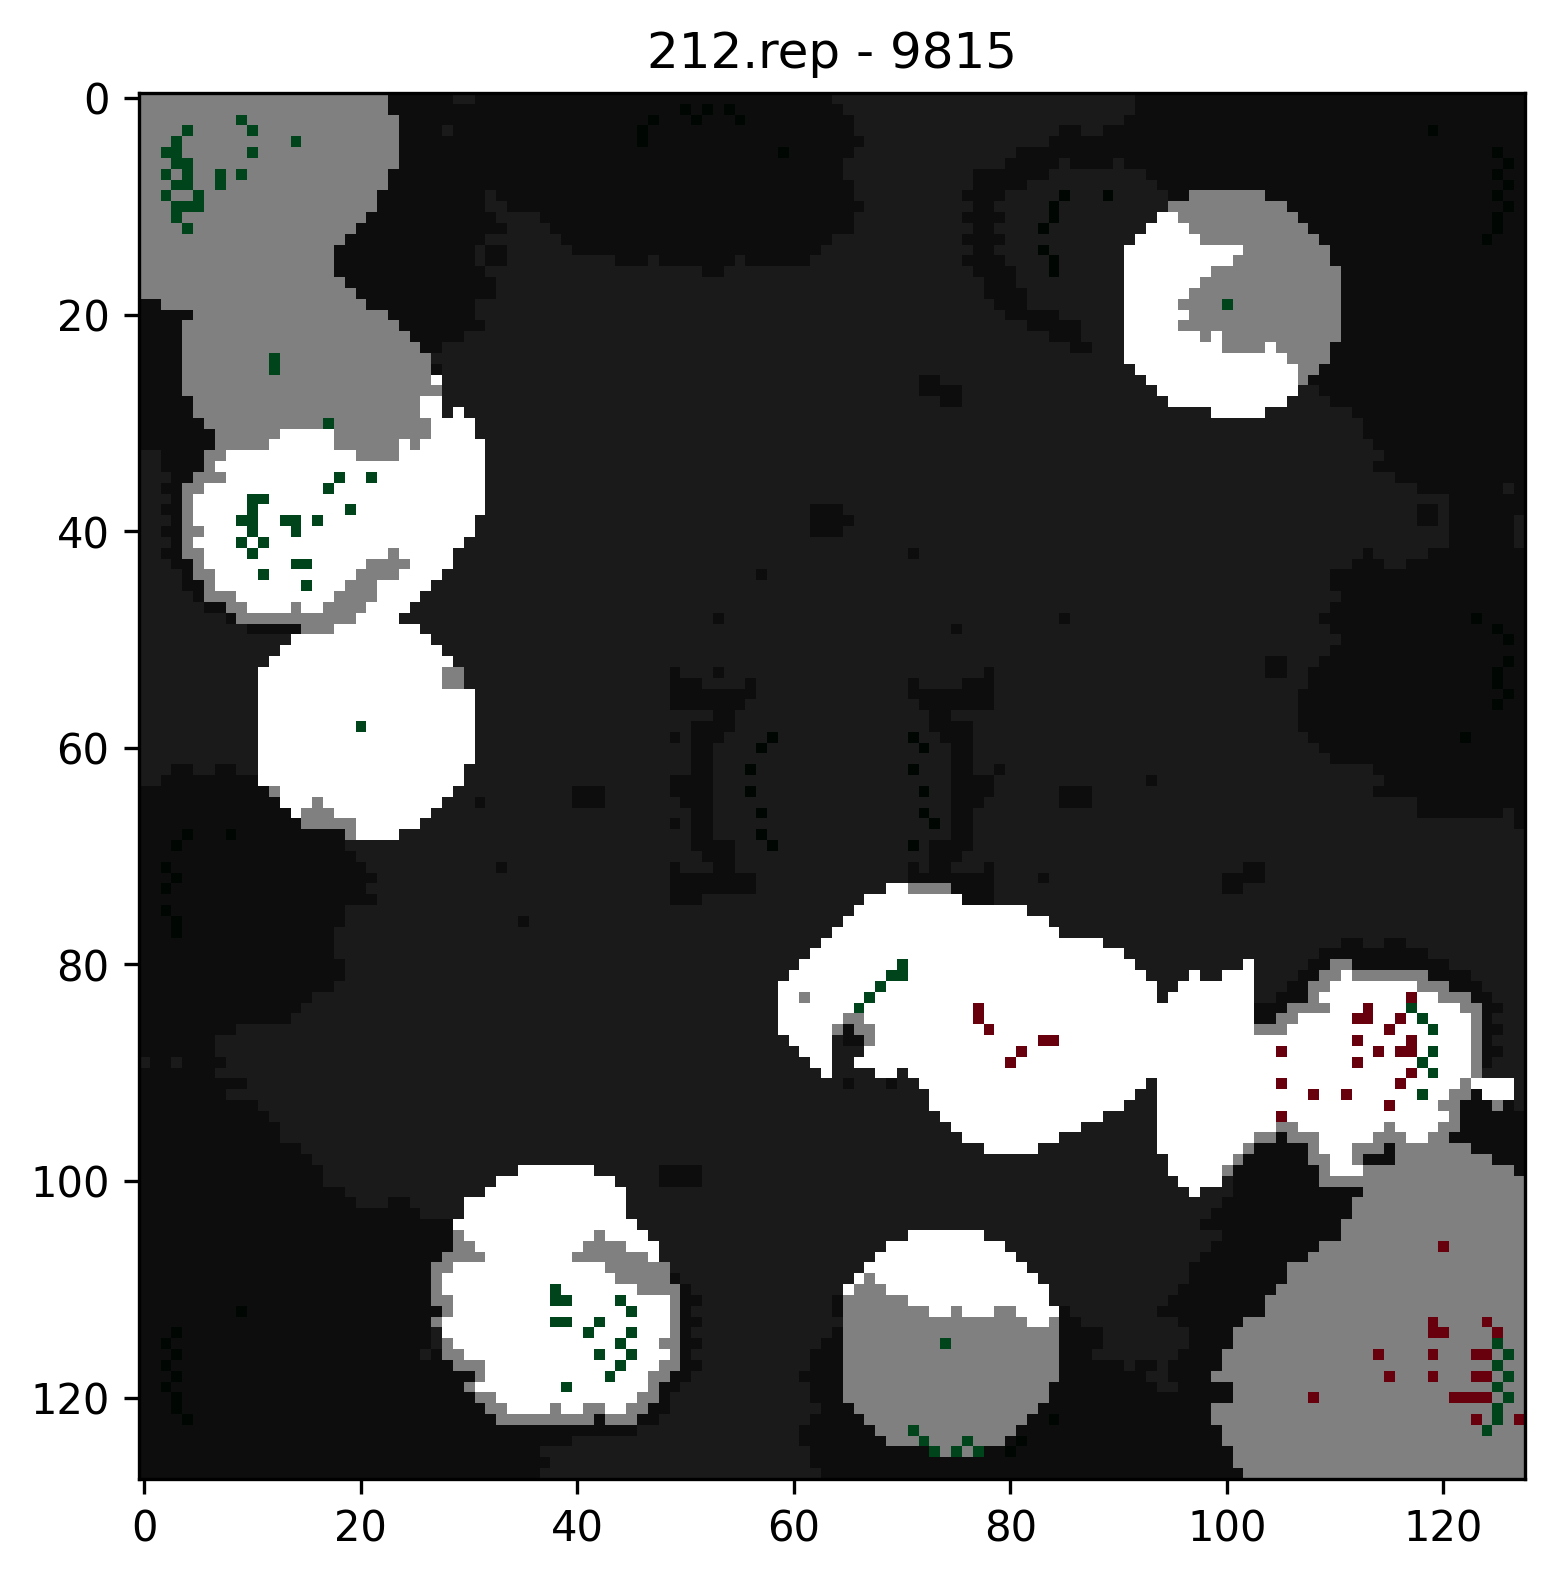

In [5]:
fig, ax = overview(data, f"{rep_name} - {frame}")

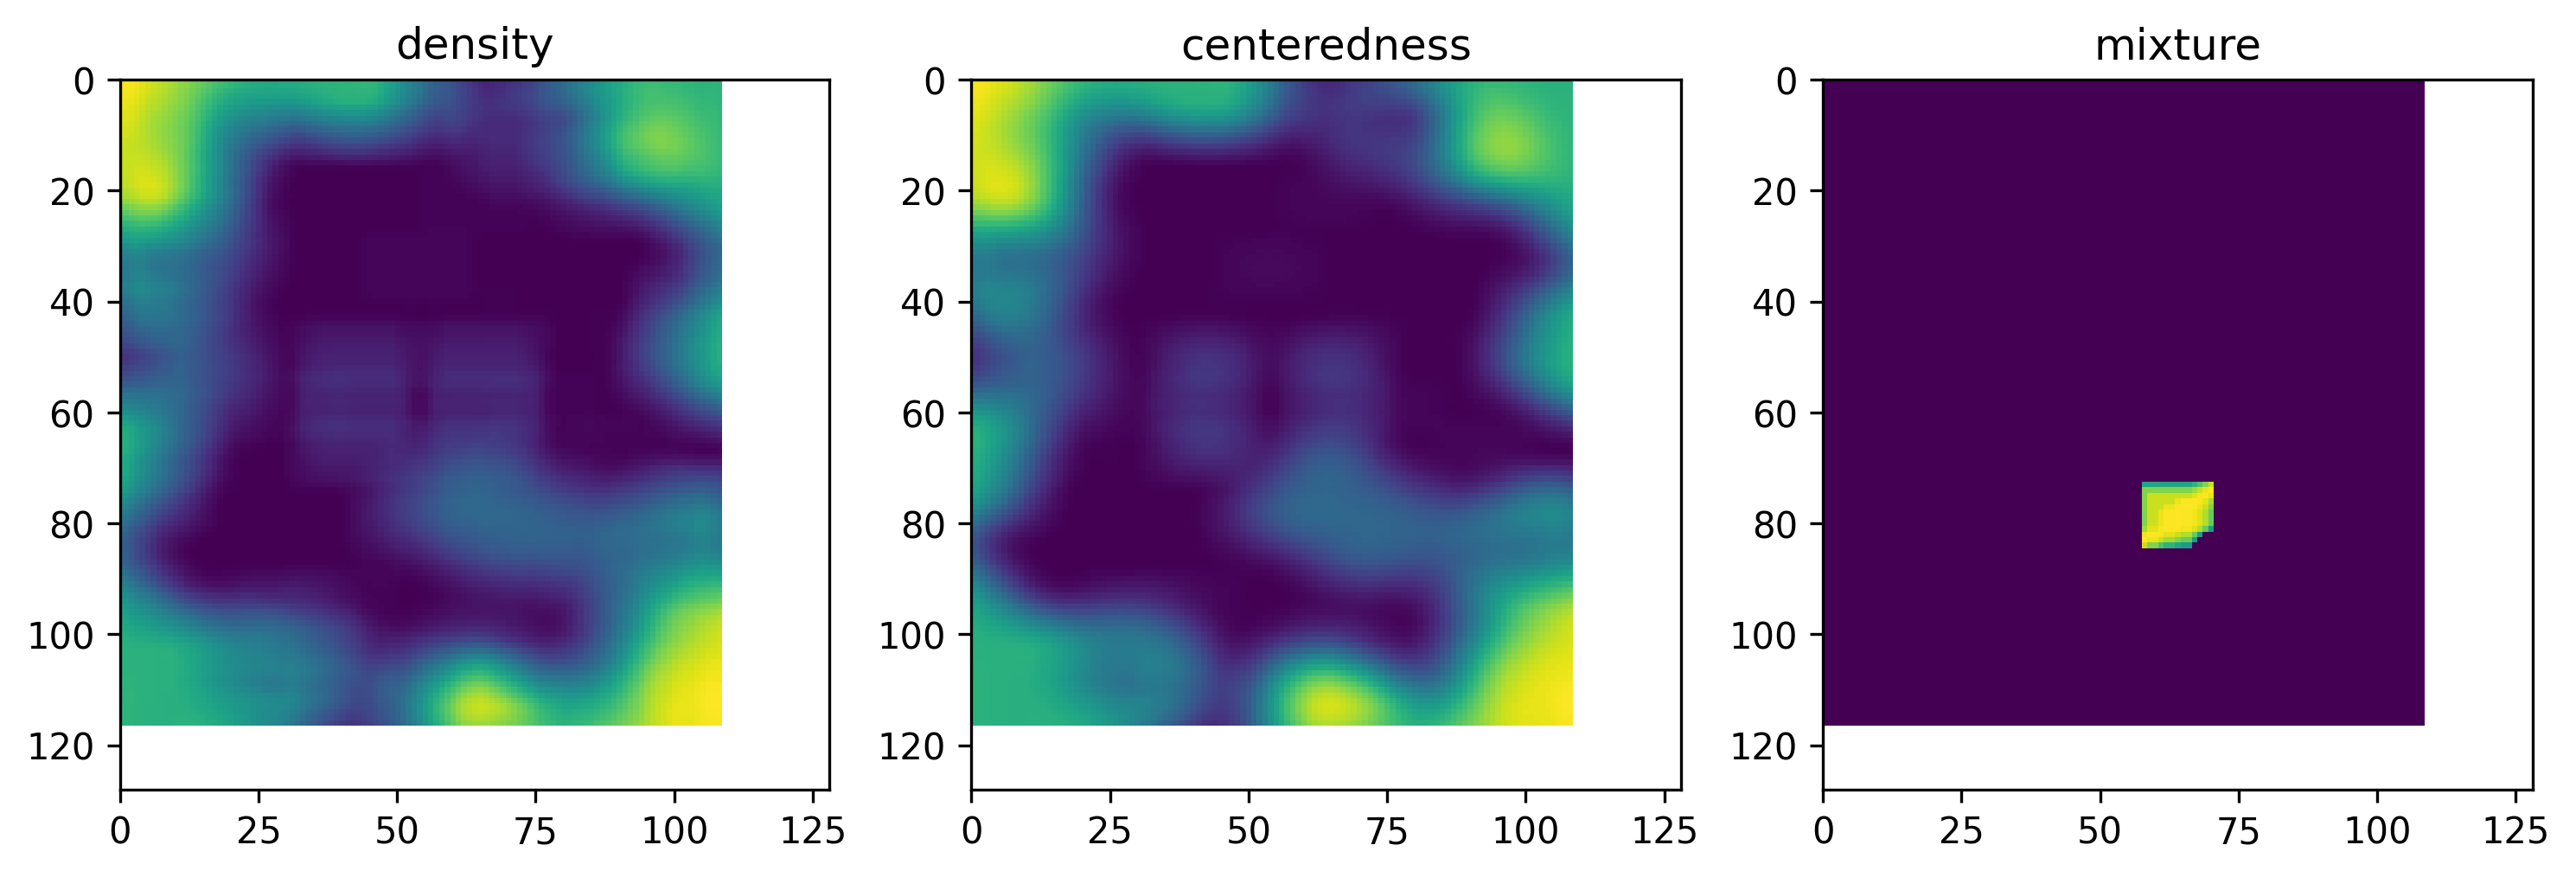

In [6]:
fig, axes = feature(cfg['data']['input_dst_dir'], rep_name, frame)

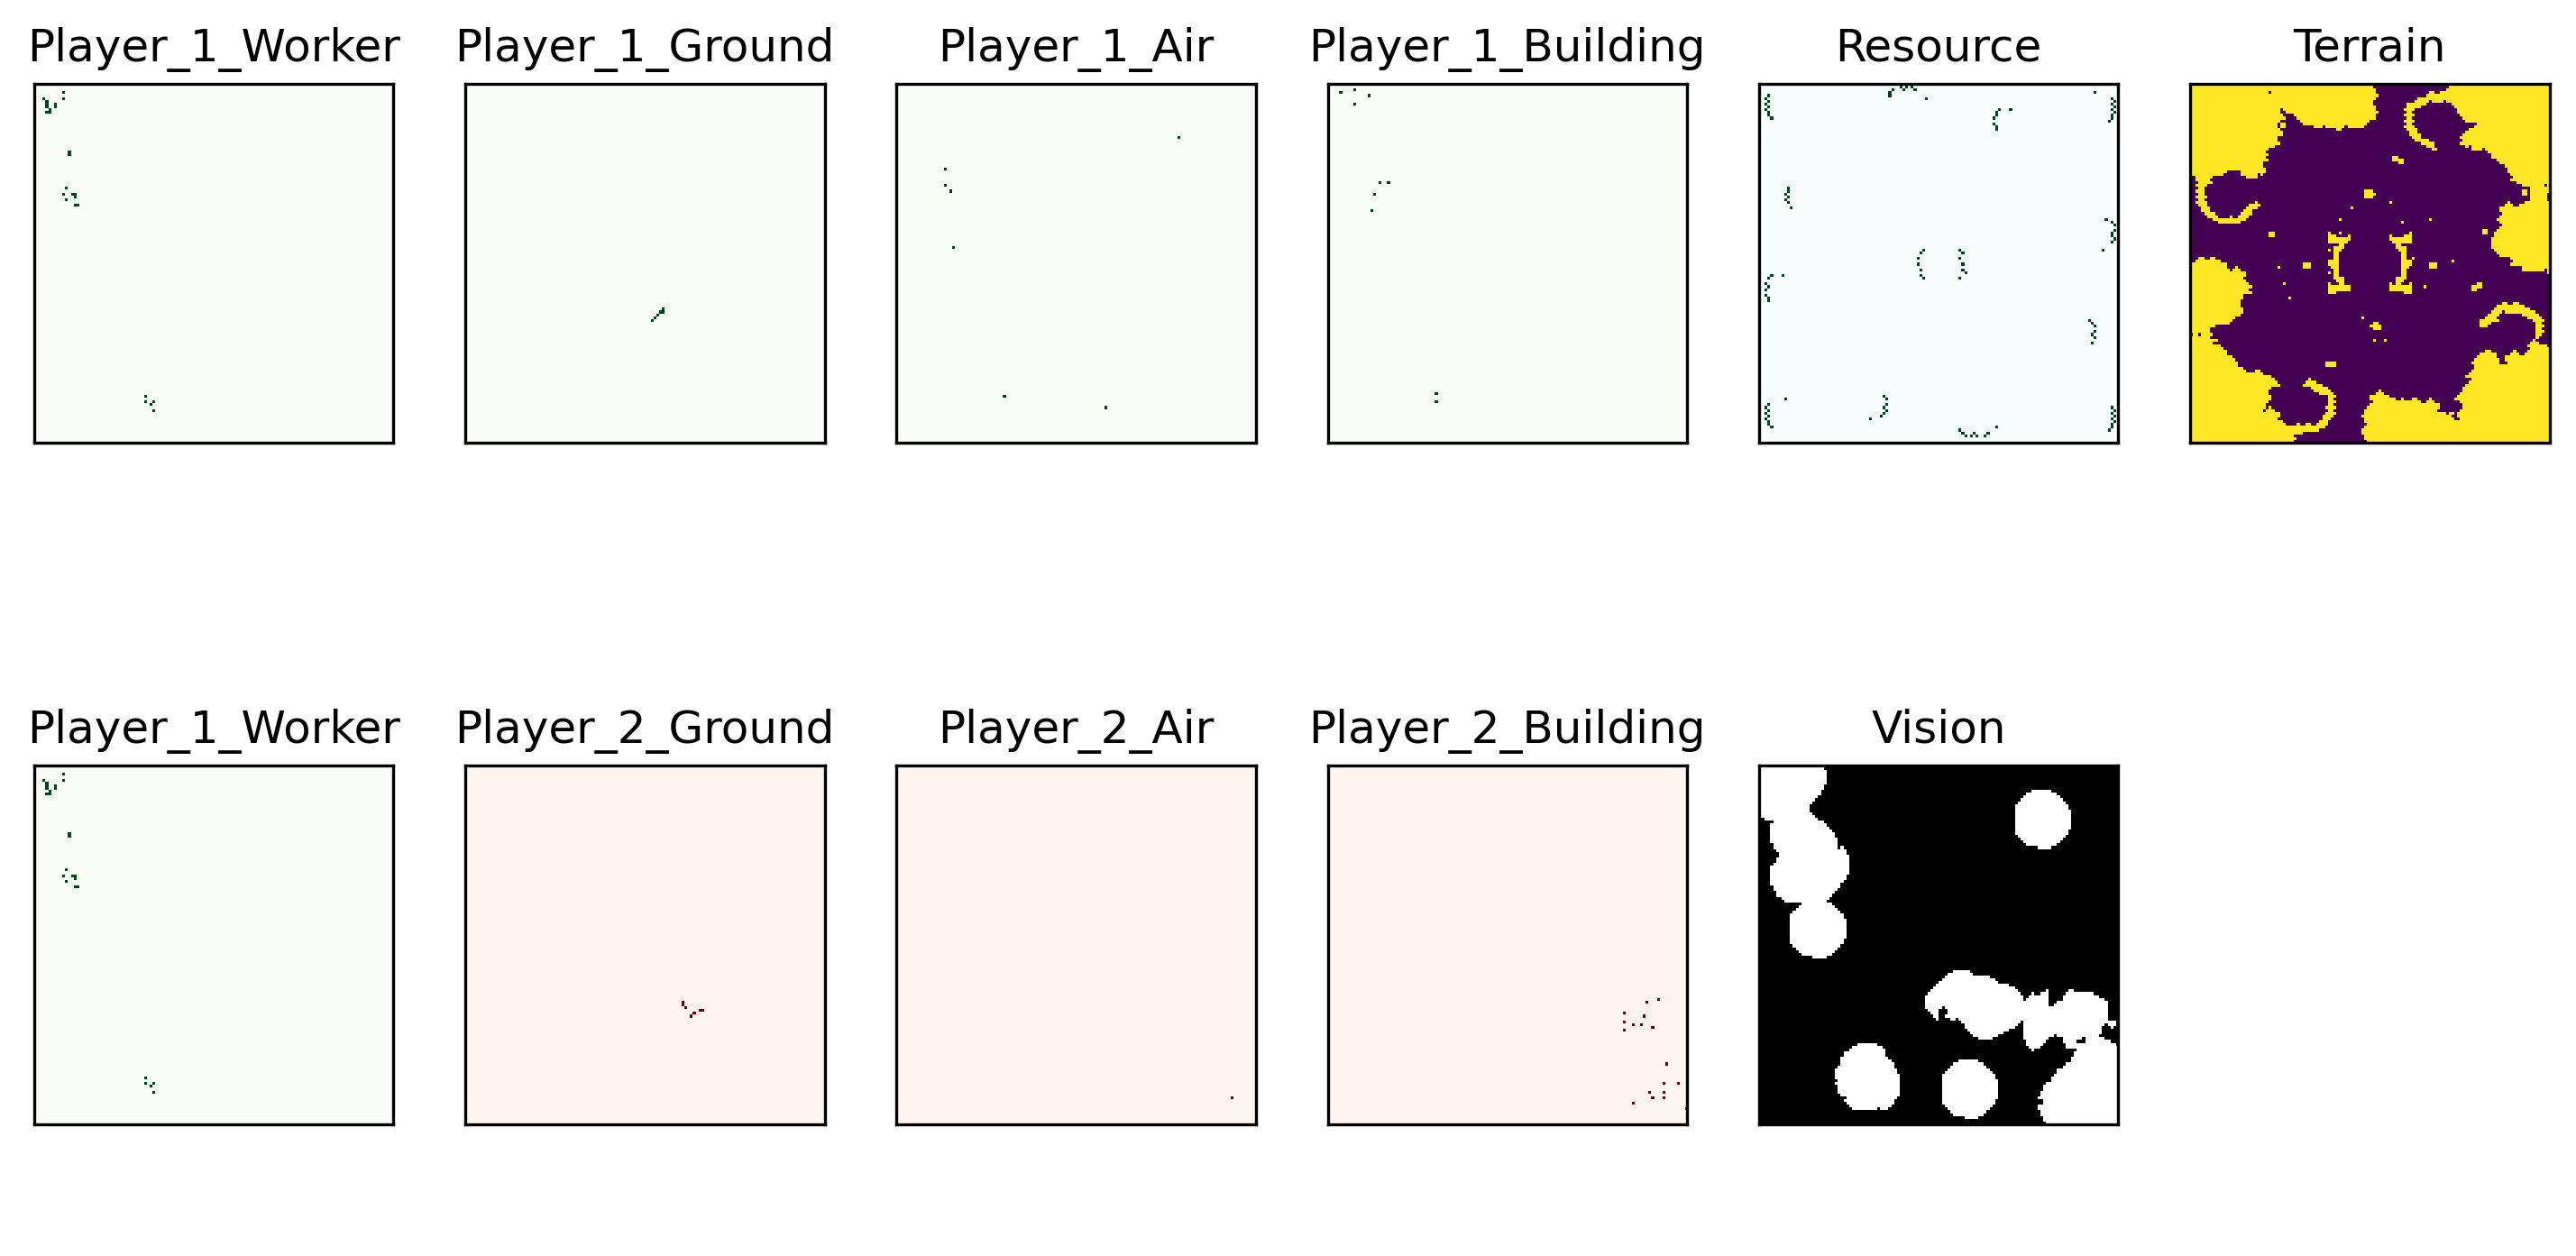

In [7]:
fig, axes = channel(data, rep_name, frame, cfg['data']['figures_dir'])

---
## 📌 Section: feature_channel_viewer.ipynb


In [1]:
import os
import glob

from enum import Enum, auto

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

|   rep    | frame | current | density |
|----------|-------|---------|---------|
| 36.rep   |  9548 |     153 |  671.80 |
| 212.rep  |  9815 |     262 |  479.09 |
| 438.rep  |  7346 |     118 |  512.25 |
| 1660.rep | 12713 |     211 |  610.23 |

&nbsp;

|   rep    | frame | current | density |
|----------|-------|---------|---------|
| 36.rep   |  9548 |     153 |  671.80 |
| 212.rep  |  9815 |     262 |  479.09 |
| 438.rep  | 19640 |     270 |  428.21 |
| 1660.rep | 12713 |     211 |  610.23 |

In [103]:
def draw_channel(data, rep_name, frame):
    import matplotlib.cm as cm

    print(f"Data shape: {data.shape}, Rep: {rep_name}, Frame: {frame}")
    
    p1_color = cm.get_cmap('Greens')(0.7)  # 'Greens'의 첫 번째 색상 (0~1 사이 인덱스)
    p2_color = cm.get_cmap('Reds')(0.7)    # 'Reds'의 첫 번째 색상
    resource_color = cm.get_cmap('GnBu')(0.7)
    
    for i in range(11):
        plt.figure(figsize=(6, 6), dpi=300)
        h, w = data[i].shape
        
        ys, xs = np.where(data[i] != 0)

        if not xs.size or not ys.size:
            print(f"Skipping channel {i} due to empty shape: {data[i].shape}")
            continue
        
        if i not in [Channel.Terrain.value, Channel.Vision.value]:
            if i in [Channel.Resource.value]:
                cmap = resource_color
            elif i in [Channel.Player_1_Worker.value, Channel.Player_1_Ground.value, Channel.Player_1_Air.value, Channel.Player_1_Building.value]:
                cmap = p1_color
            elif i in [Channel.Player_2_Worker.value, Channel.Player_2_Ground.value, Channel.Player_2_Air.value, Channel.Player_2_Building.value]:
                cmap = p2_color

            plt.scatter(xs, ys, s=100, c=[cmap], edgecolors='black', marker='s')
            plt.gca().set_aspect('equal')   # 축 비율을 1:1로
            plt.xlim(0, w)
            plt.ylim(h, 0)
        elif i == Channel.Terrain.value:
            plt.imshow(data[i], cmap='viridis')
        elif i == Channel.Vision.value:
            plt.imshow(data[i], cmap='gray', alpha=0.7)
        else:
            plt.imshow(data[i], cmap='Greys', alpha=0.5)
        # plt.title(Channel(i).name)
        plt.xticks([])
        plt.yticks([])
        # plt.axis('off')
        plt.tight_layout()
        # plt.show()
        os.makedirs(f"figures/{rep_name}", exist_ok=True)
        plt.savefig(f"figures/{rep_name}/figure_{rep_name}_{frame}_{Channel(i).name}.png")

In [ ]:
def draw_overview(data, rep_name, frame):
    plt.figure(figsize=(6, 6), dpi=300)

    terrain_img = plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    resource_img = plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    p1_cmap='Greens'
    p2_cmap='Reds'

    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    player_1_worker_img = plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    player_2_worker_img = plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    player_1_ground_img = plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    player_2_ground_img = plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    player_1_air_img = plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    player_2_air_img = plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    player_1_building_img = plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    player_2_building_img = plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)
    
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    vision_img = plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)
    # m = plt.imshow(vision_alpha, cmap='Greys', alpha=vision_alpha)
    # vision_img = plt.imshow(data[Channel.Vision.value] == 1, cmap='Greys', alpha=1)

    plt.axis('off')

    plt.tight_layout()
    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(f'figures/{rep_name}/{rep_name}_{frame}_Overview.png', bbox_inches='tight', pad_inches=0)
    # plt.show()

In [67]:
rep_dir = "data/input/dst/"
rep_name = "212.rep"
frame = 9815


In [68]:
# data = zarr.load(npzs[frame])
data = np.load(os.path.join(rep_dir, f"{rep_name}/{frame}.npy"))
print(f"Loaded data for {rep_name} at frame {frame}")


Loaded data for 212.rep at frame 9815


Data shape: (11, 128, 128), Rep: 212.rep, Frame: 9815


/tmp/ipykernel_3445284/2432329567.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  p1_color = cm.get_cmap('Greens')(0.7)  # 'Greens'의 첫 번째 색상 (0~1 사이 인덱스)
/tmp/ipykernel_3445284/2432329567.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  p2_color = cm.get_cmap('Reds')(0.7)    # 'Reds'의 첫 번째 색상
/tmp/ipykernel_3445284/2432329567.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  resource_color = cm.get_cmap('GnBu')(0.7)


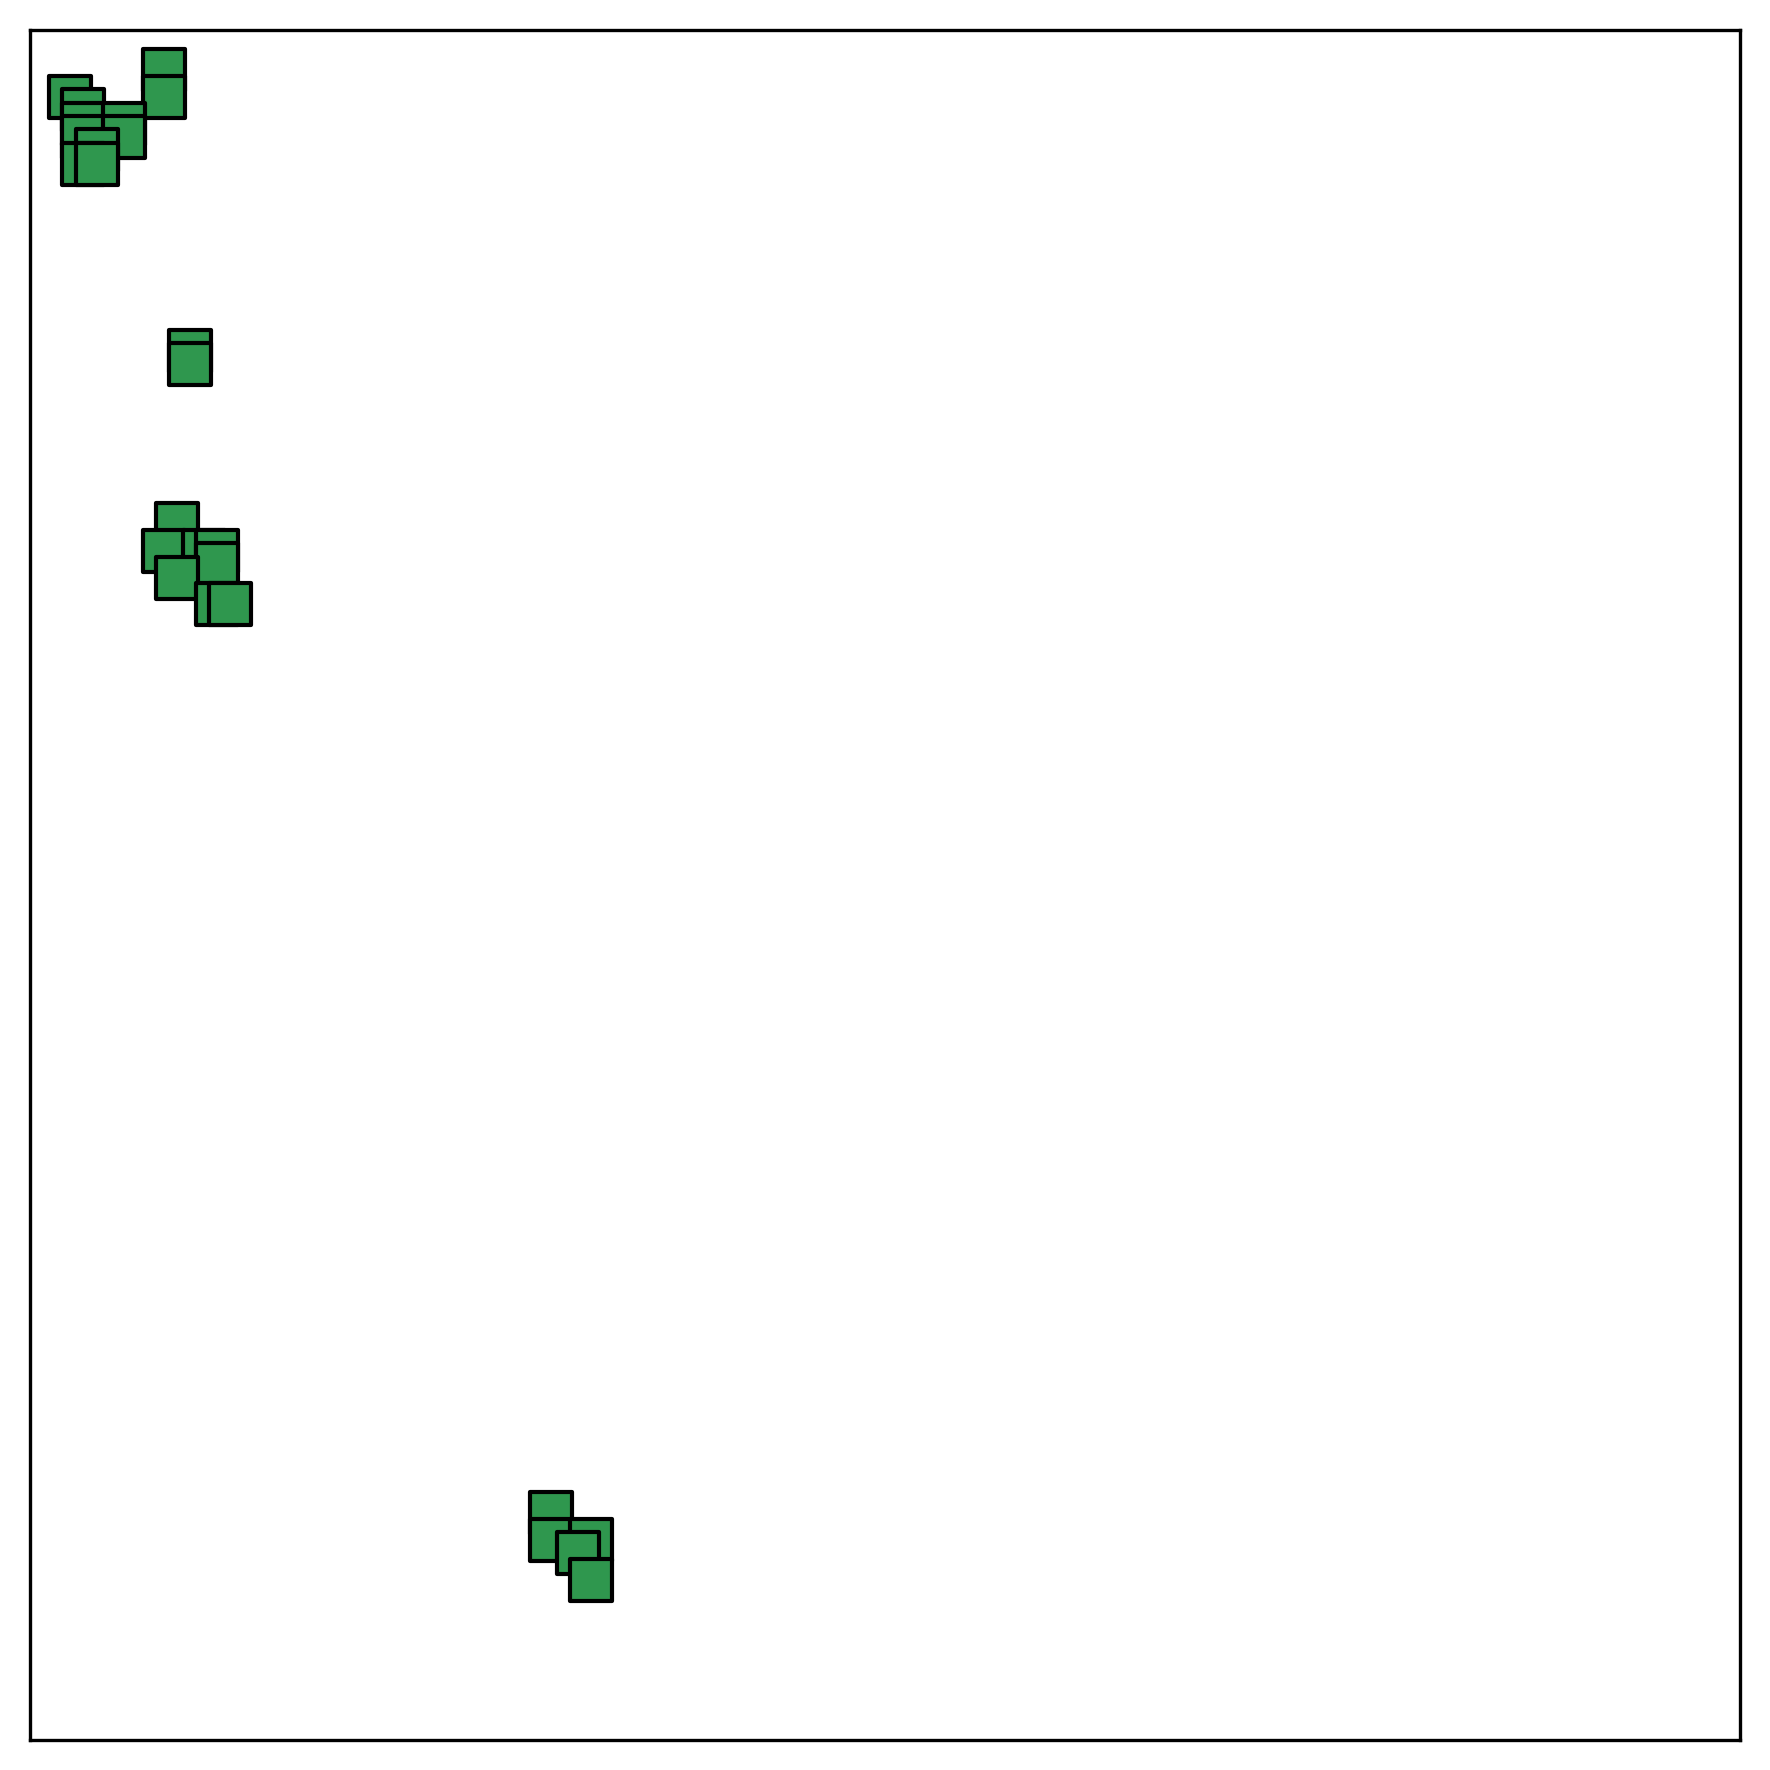

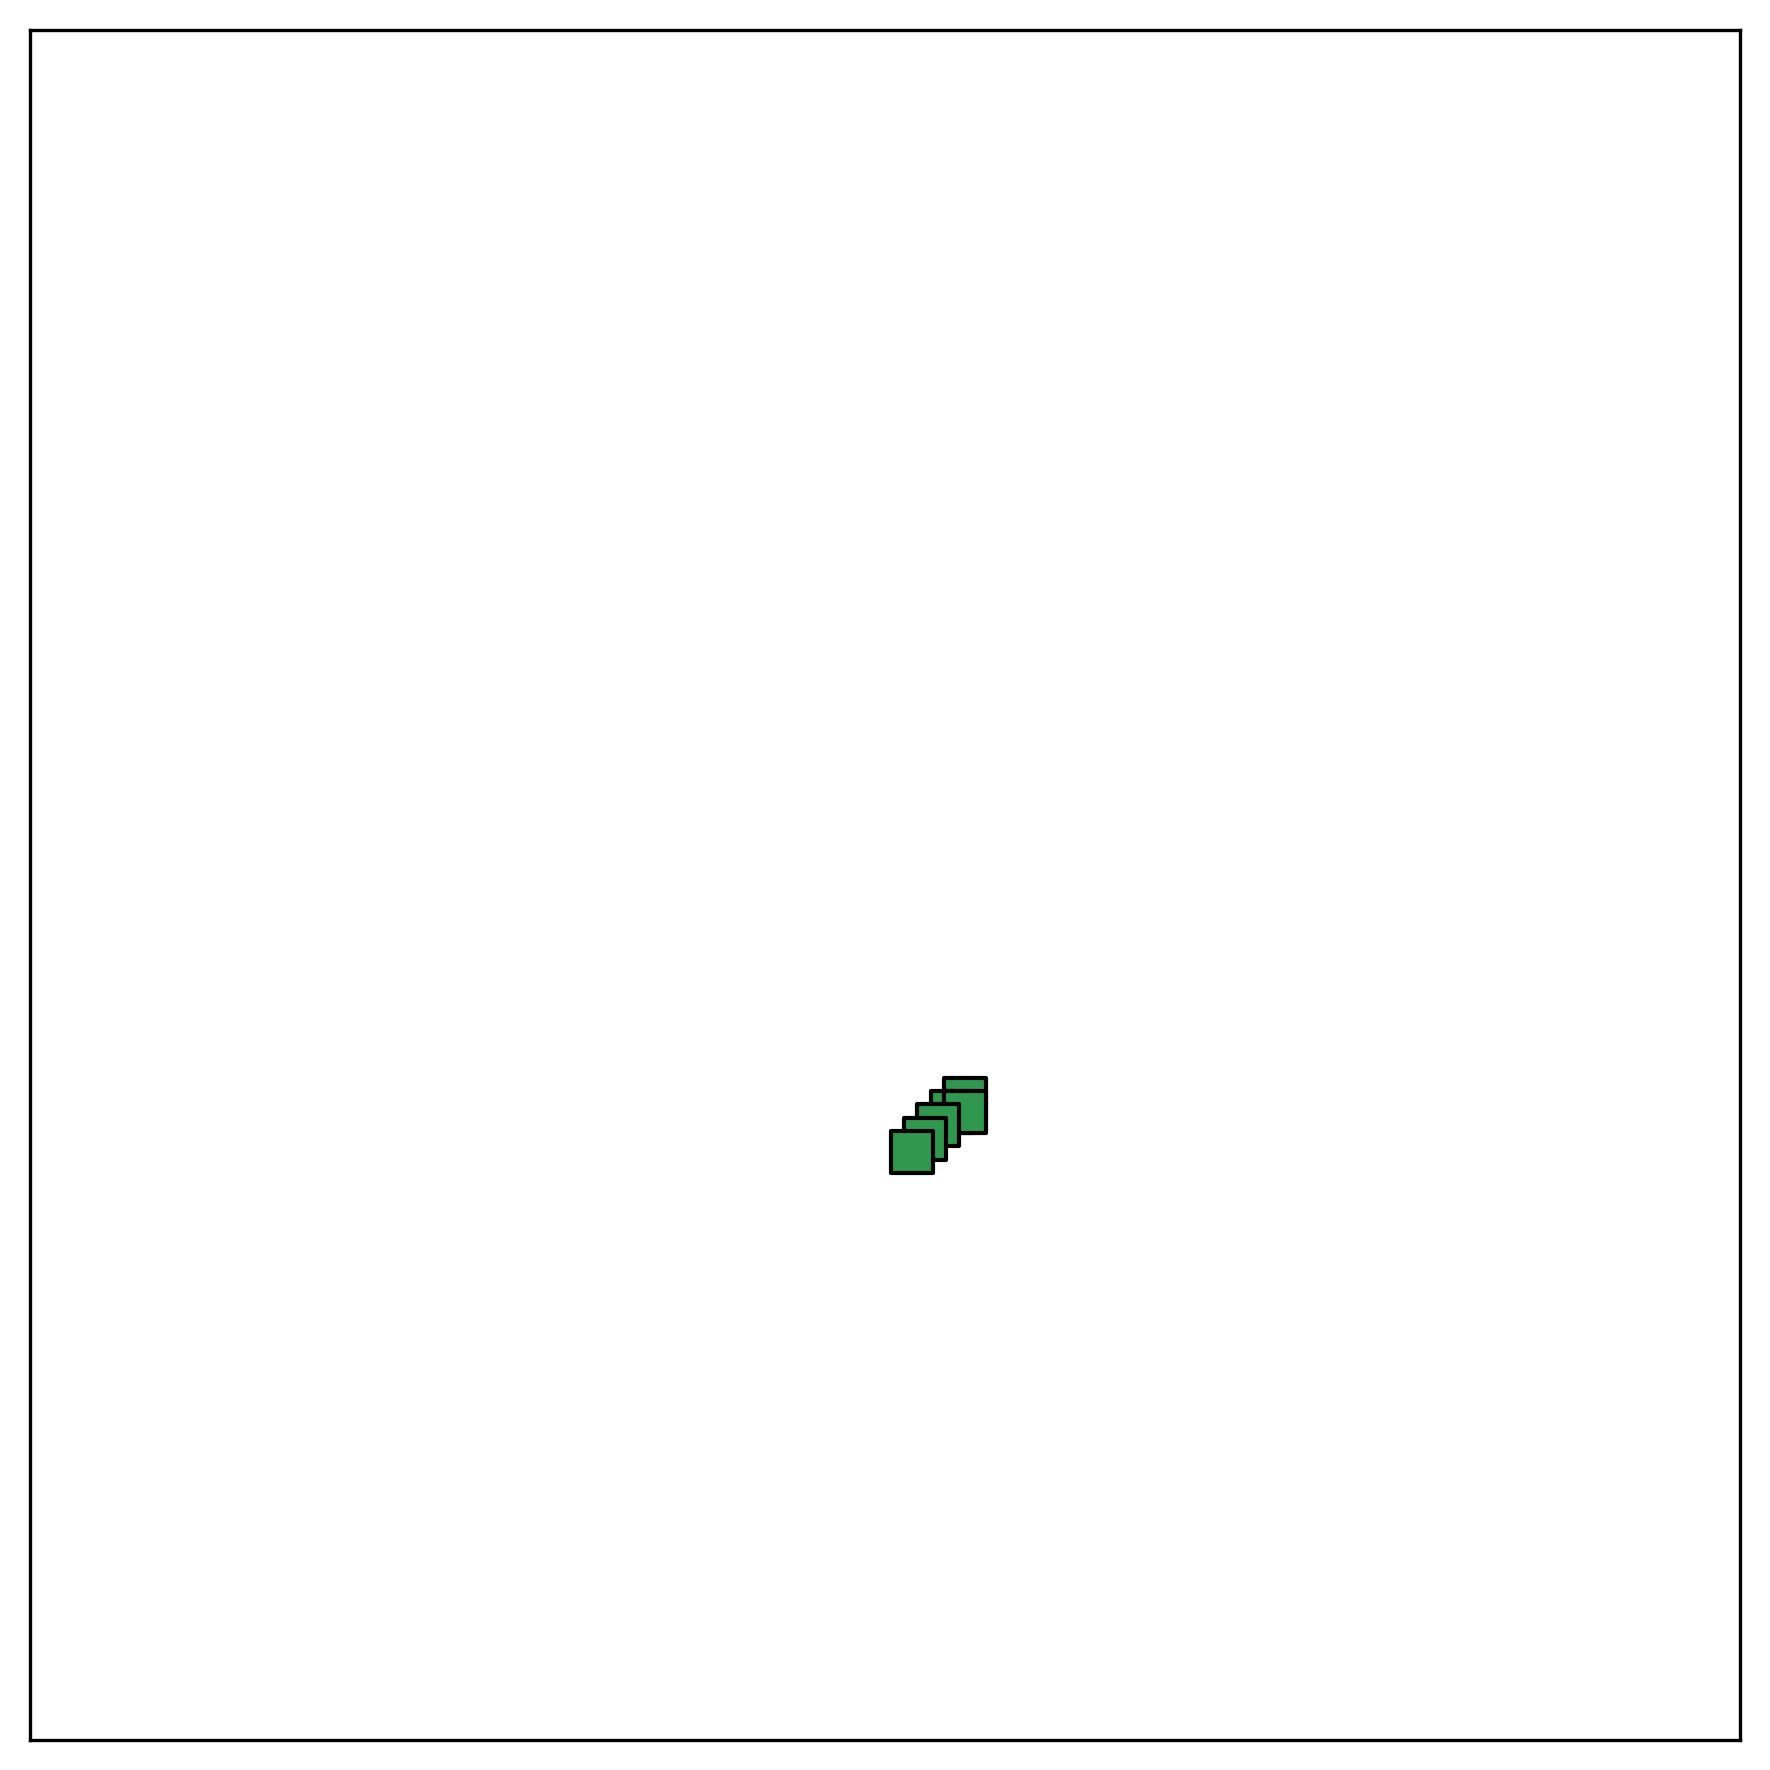

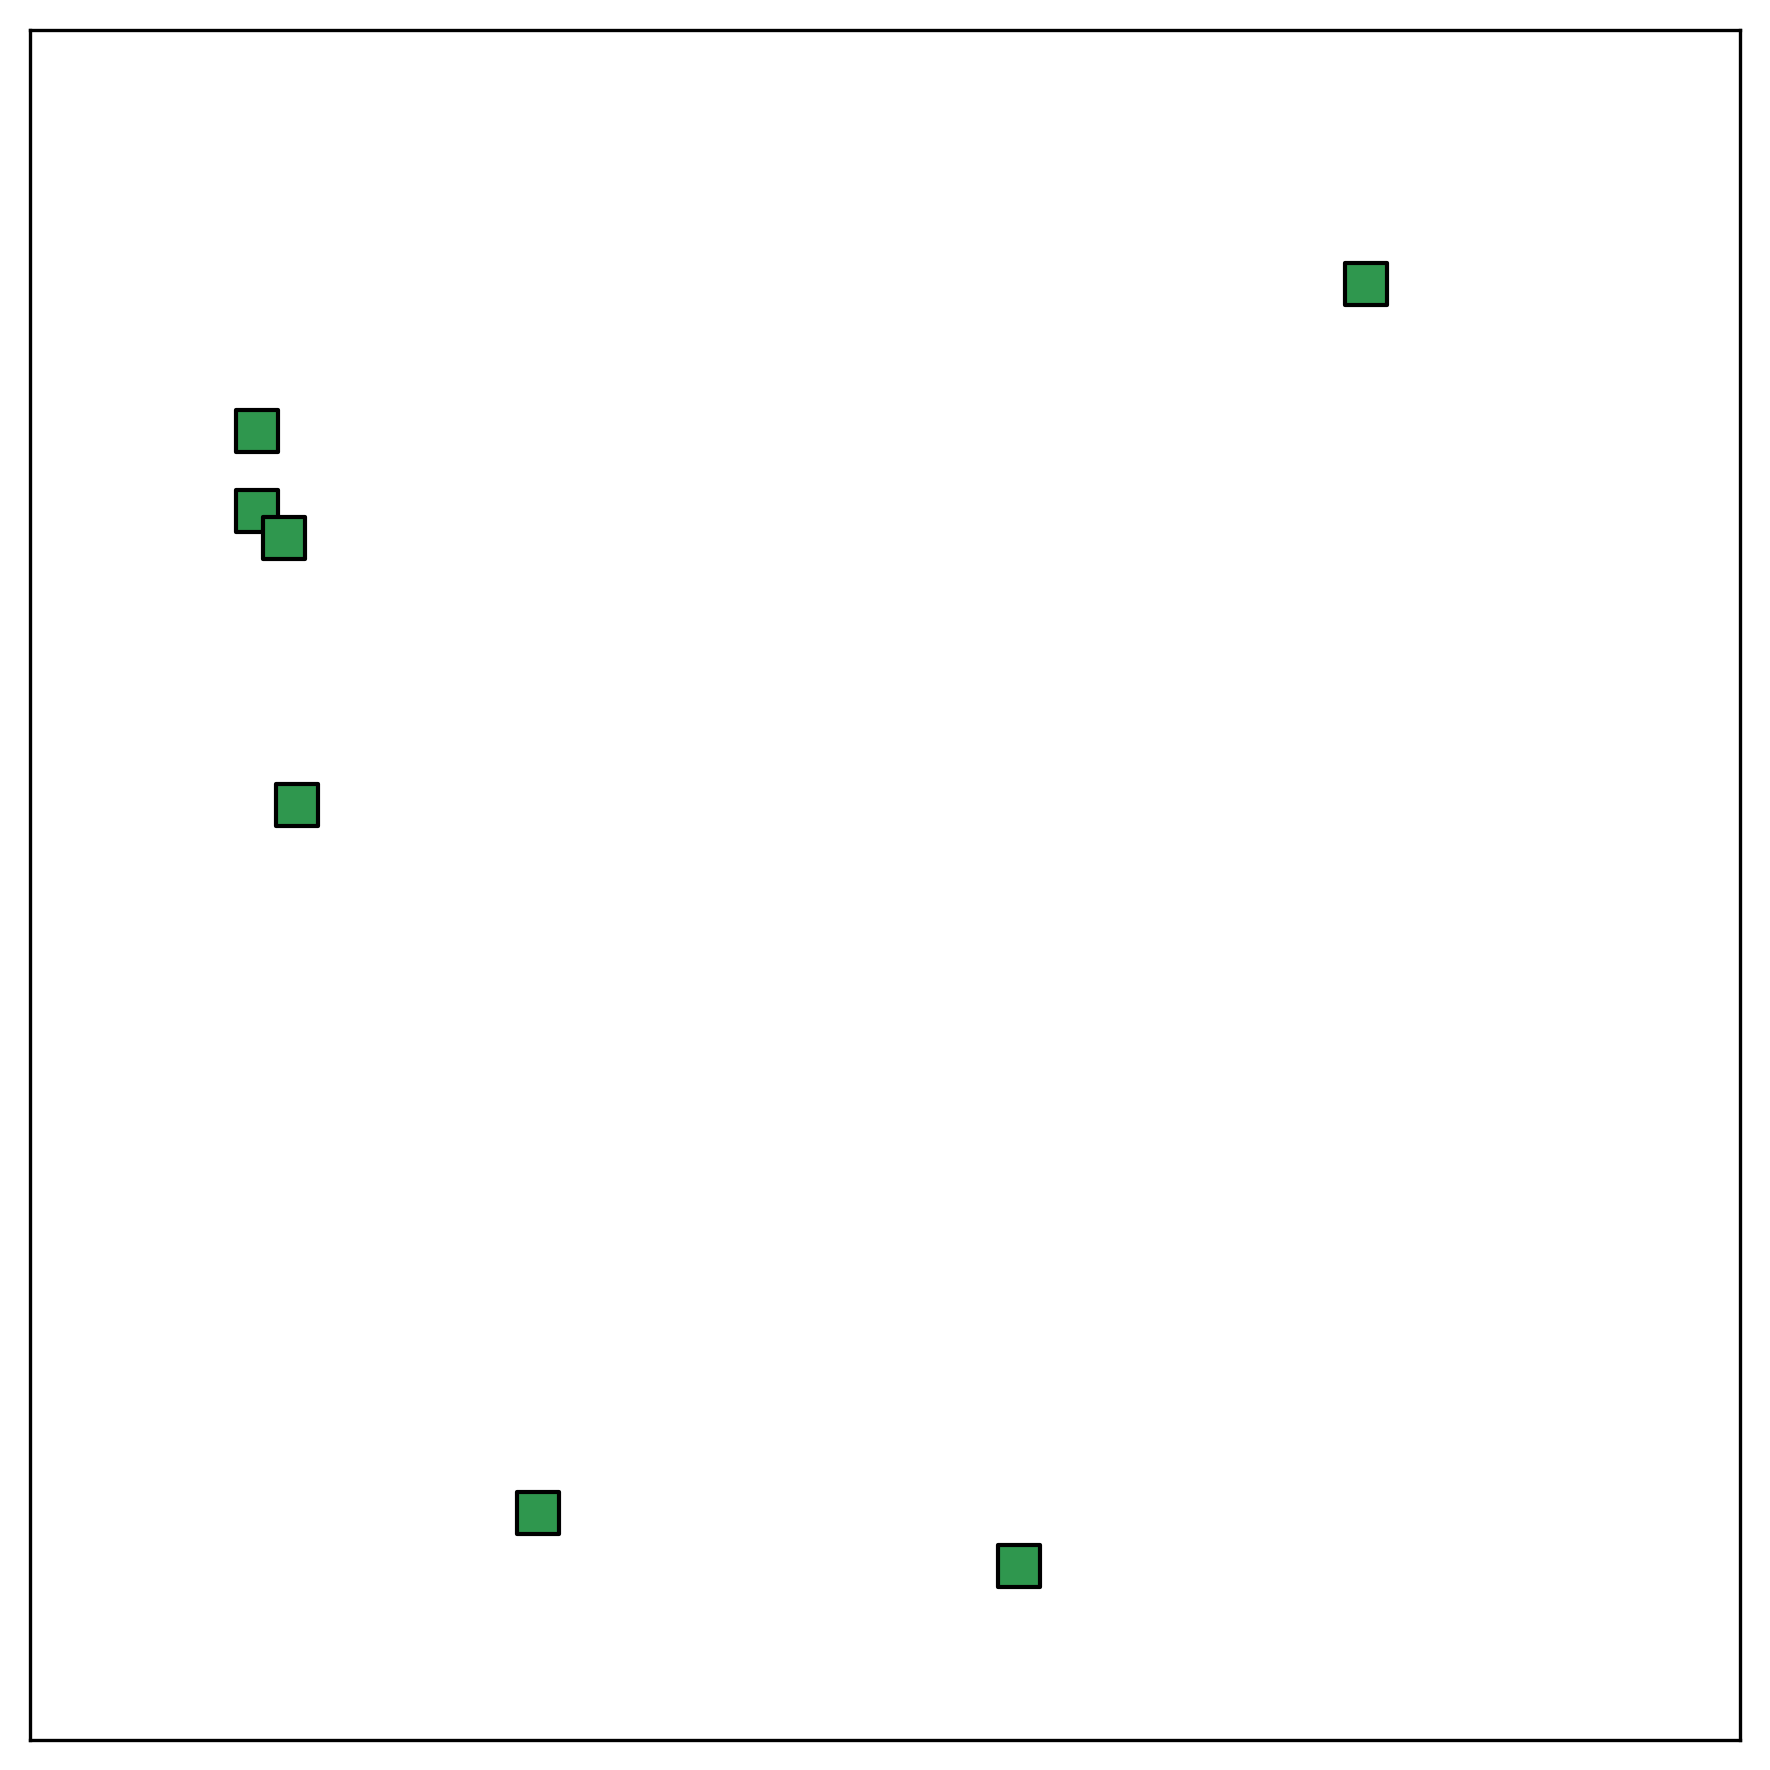

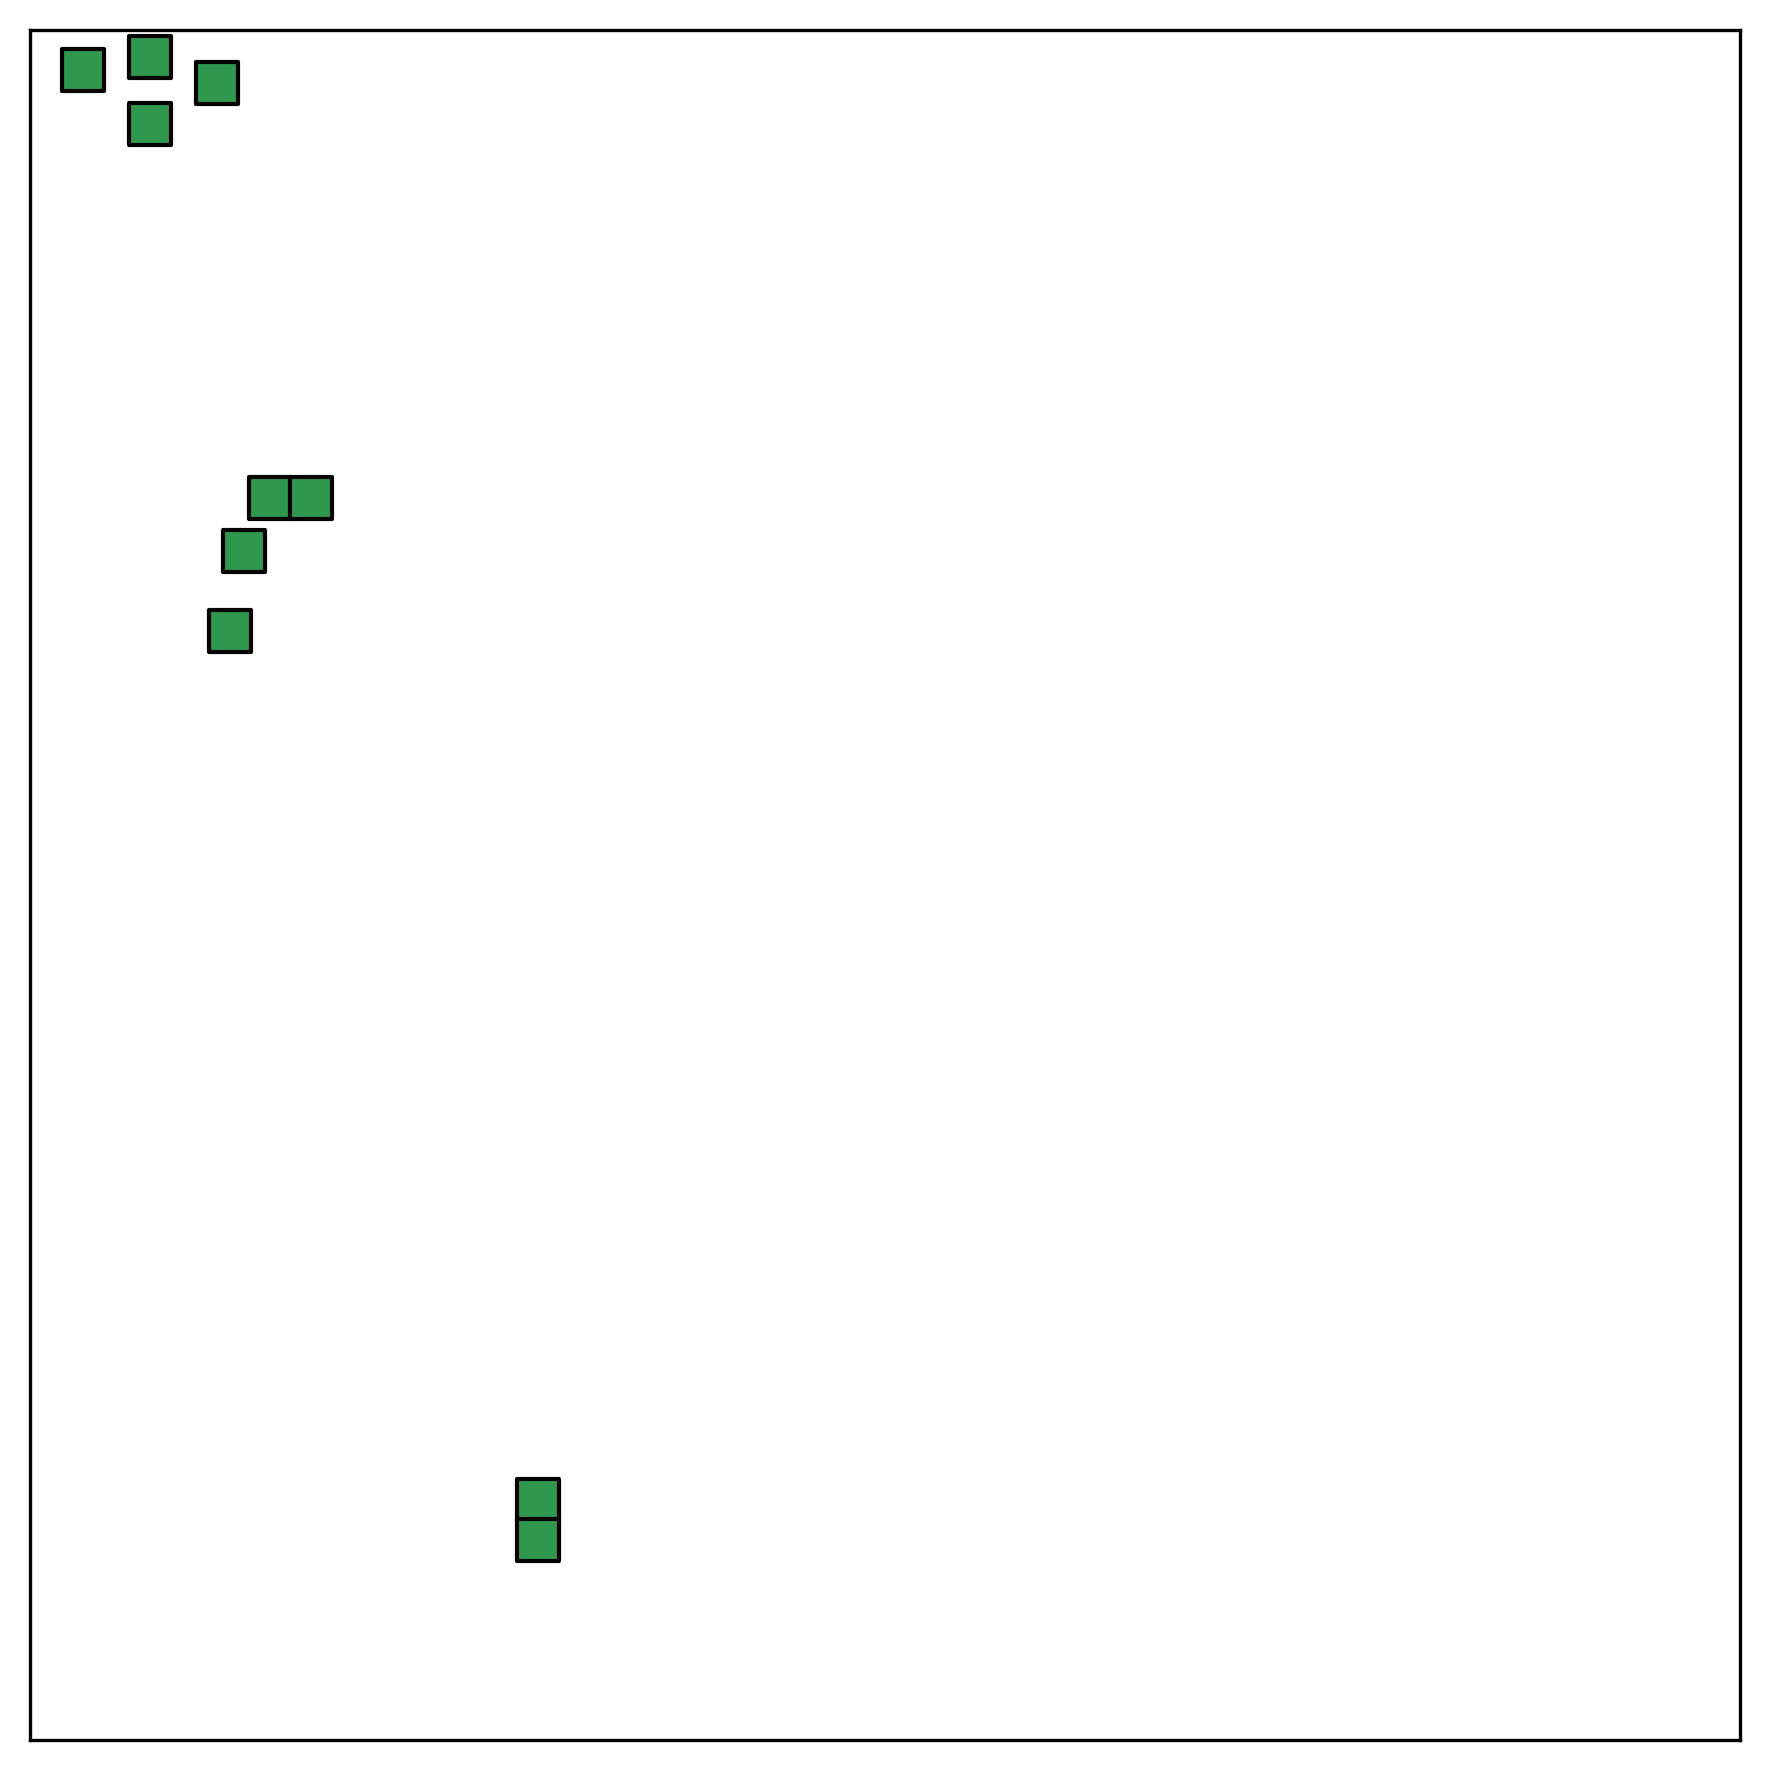

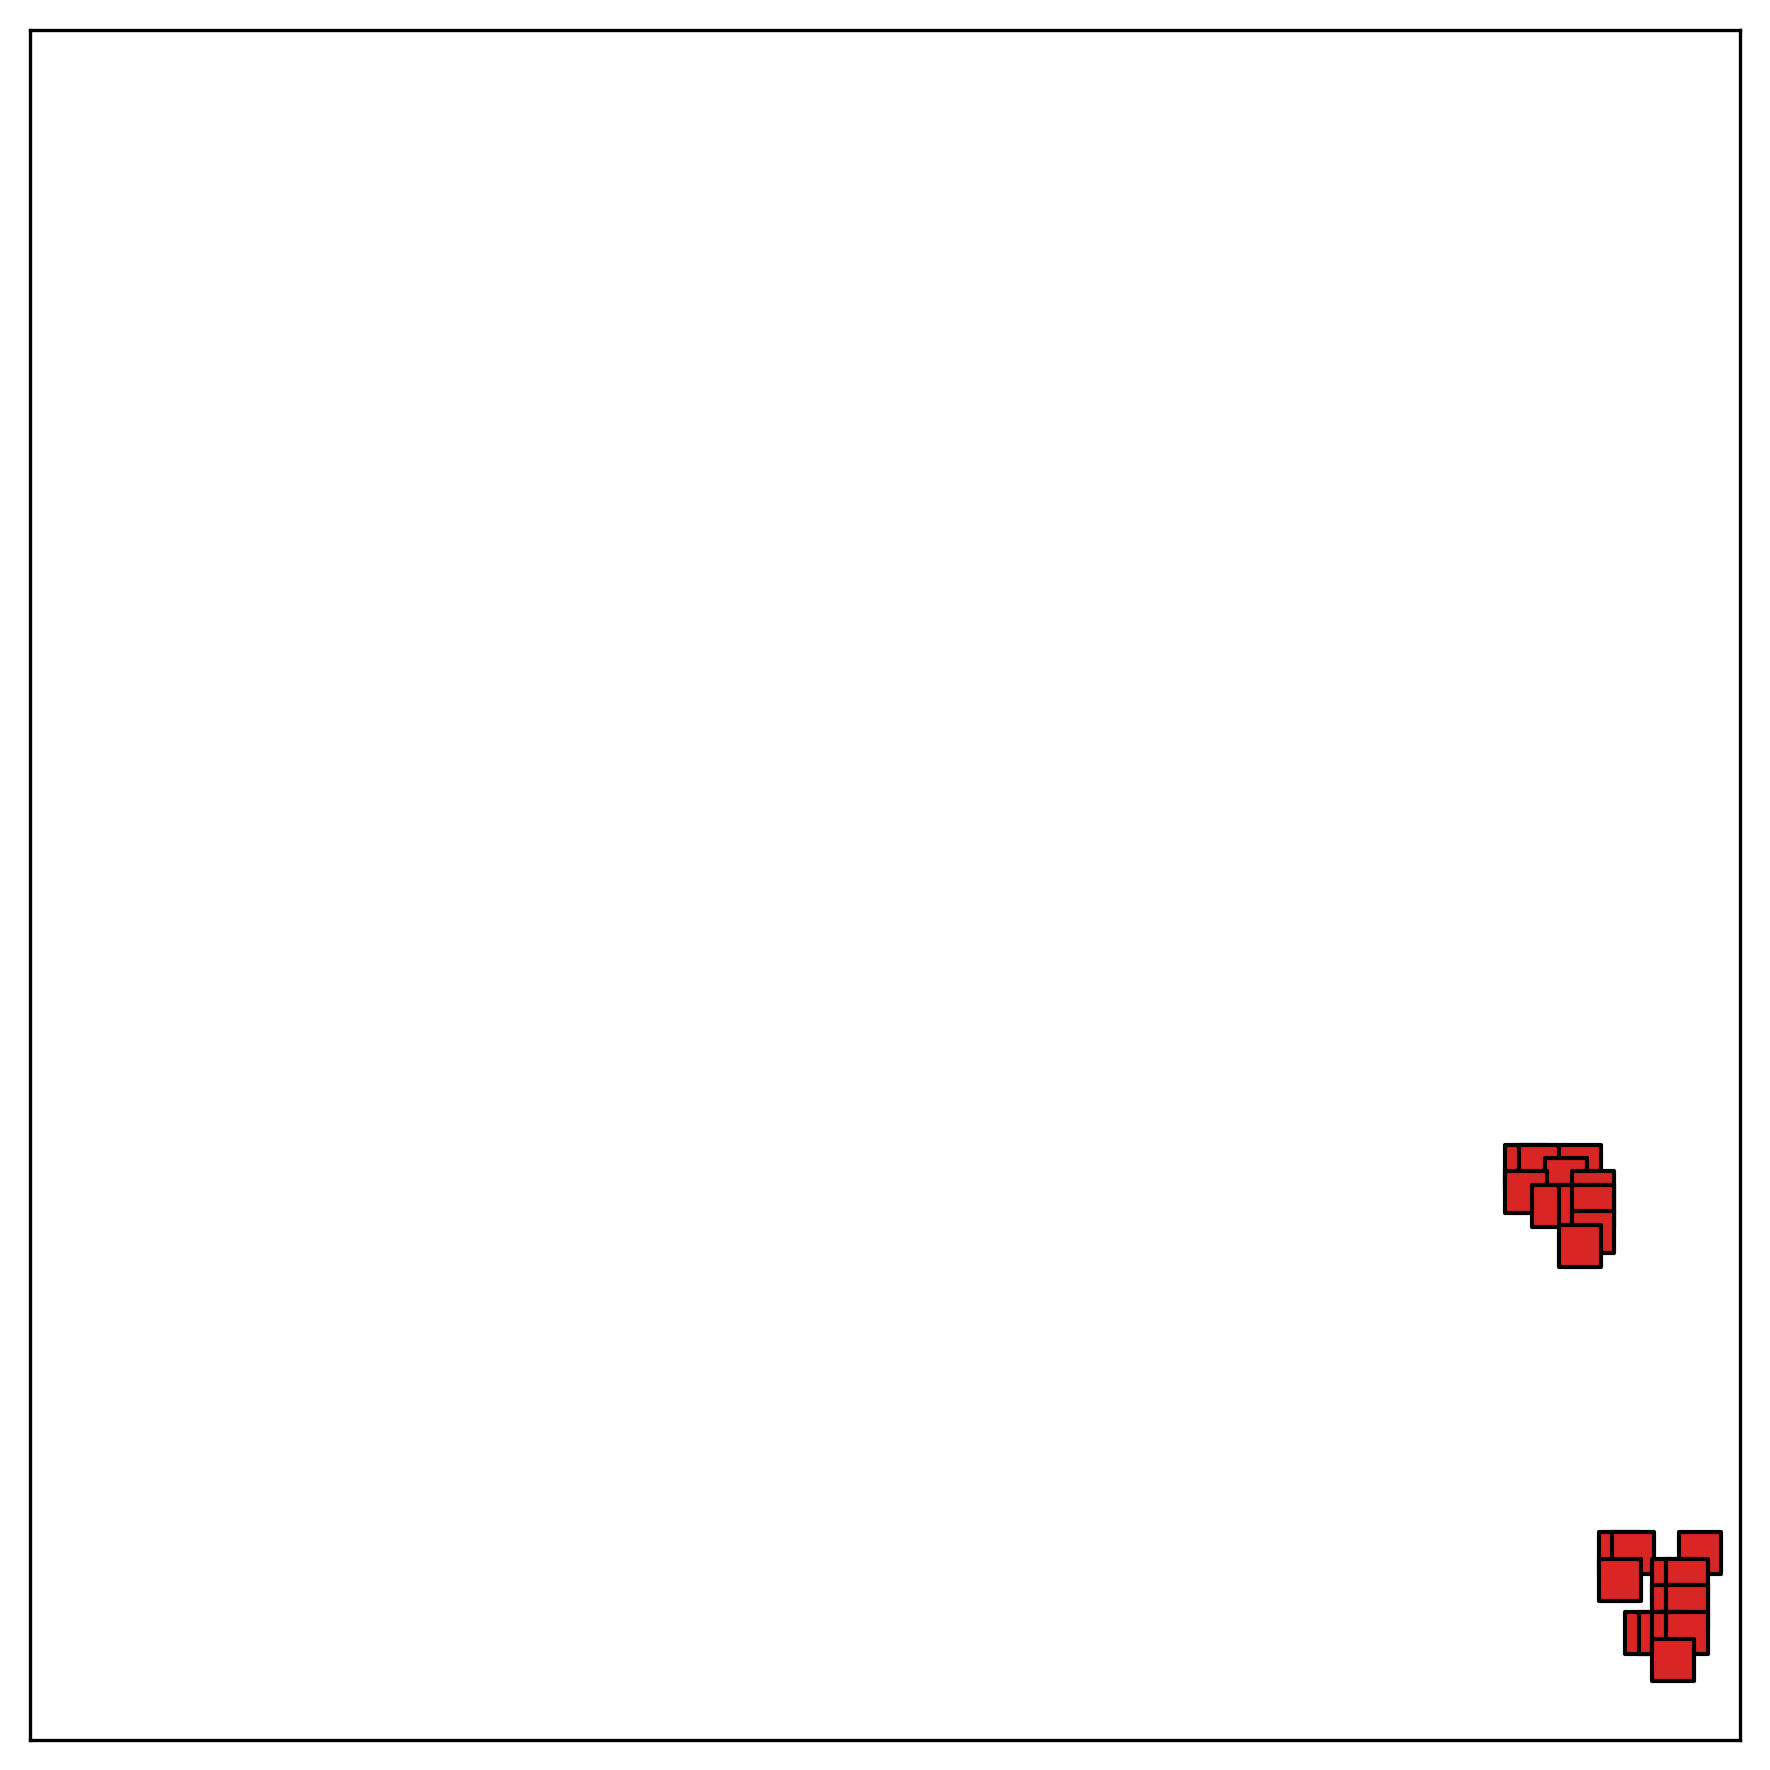

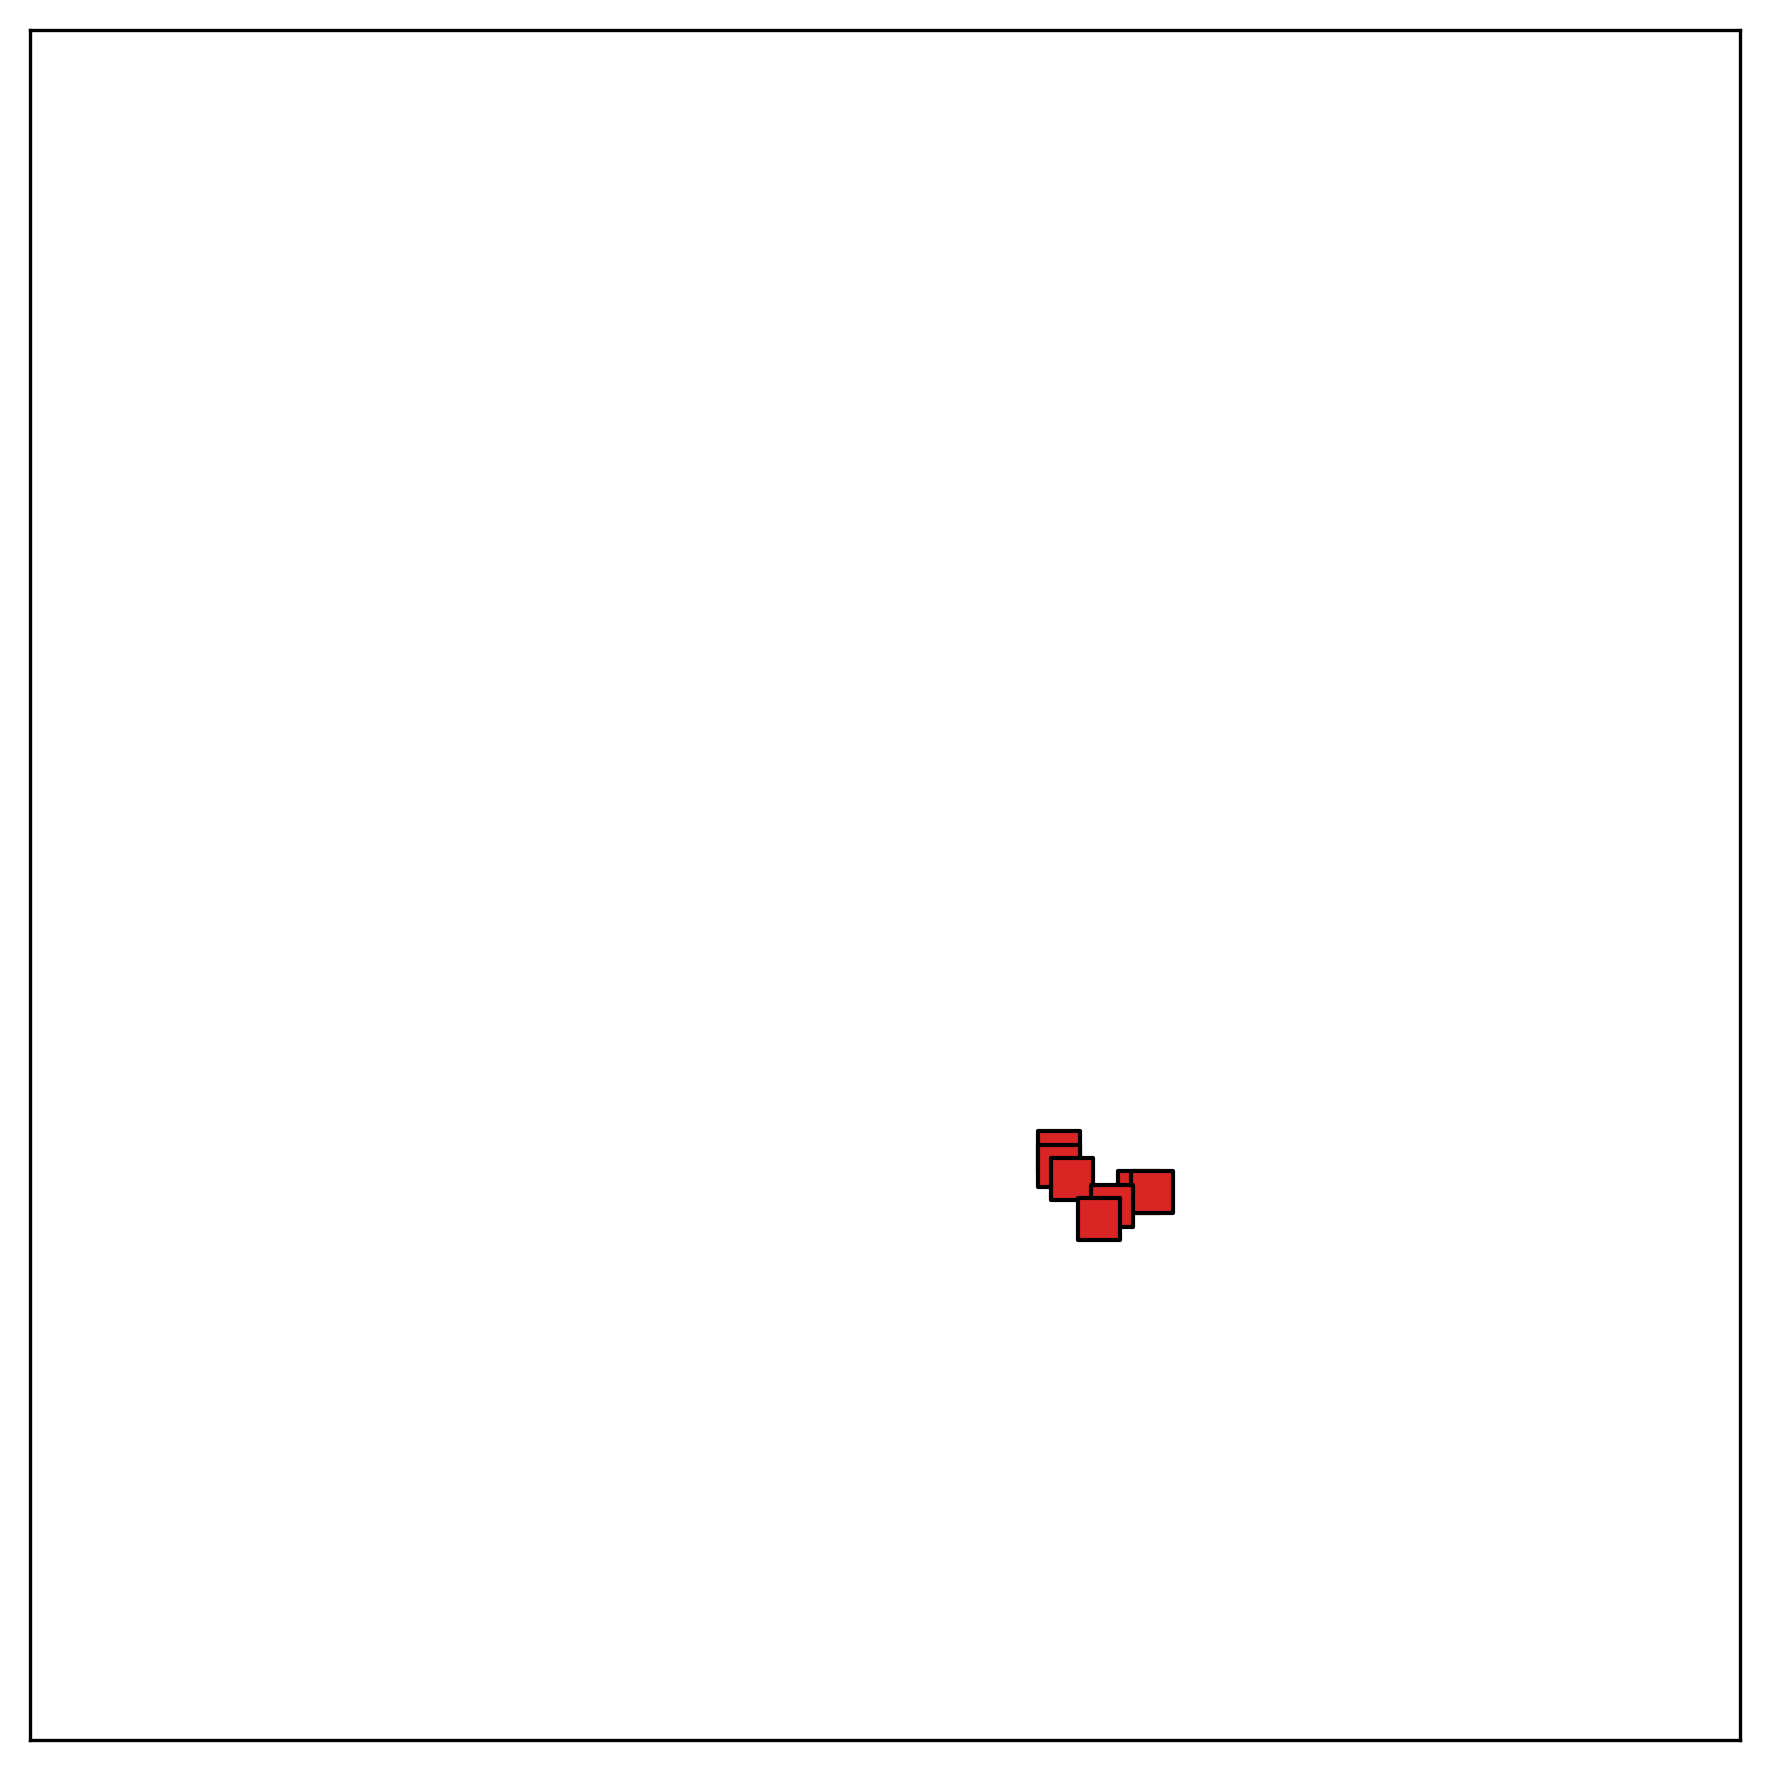

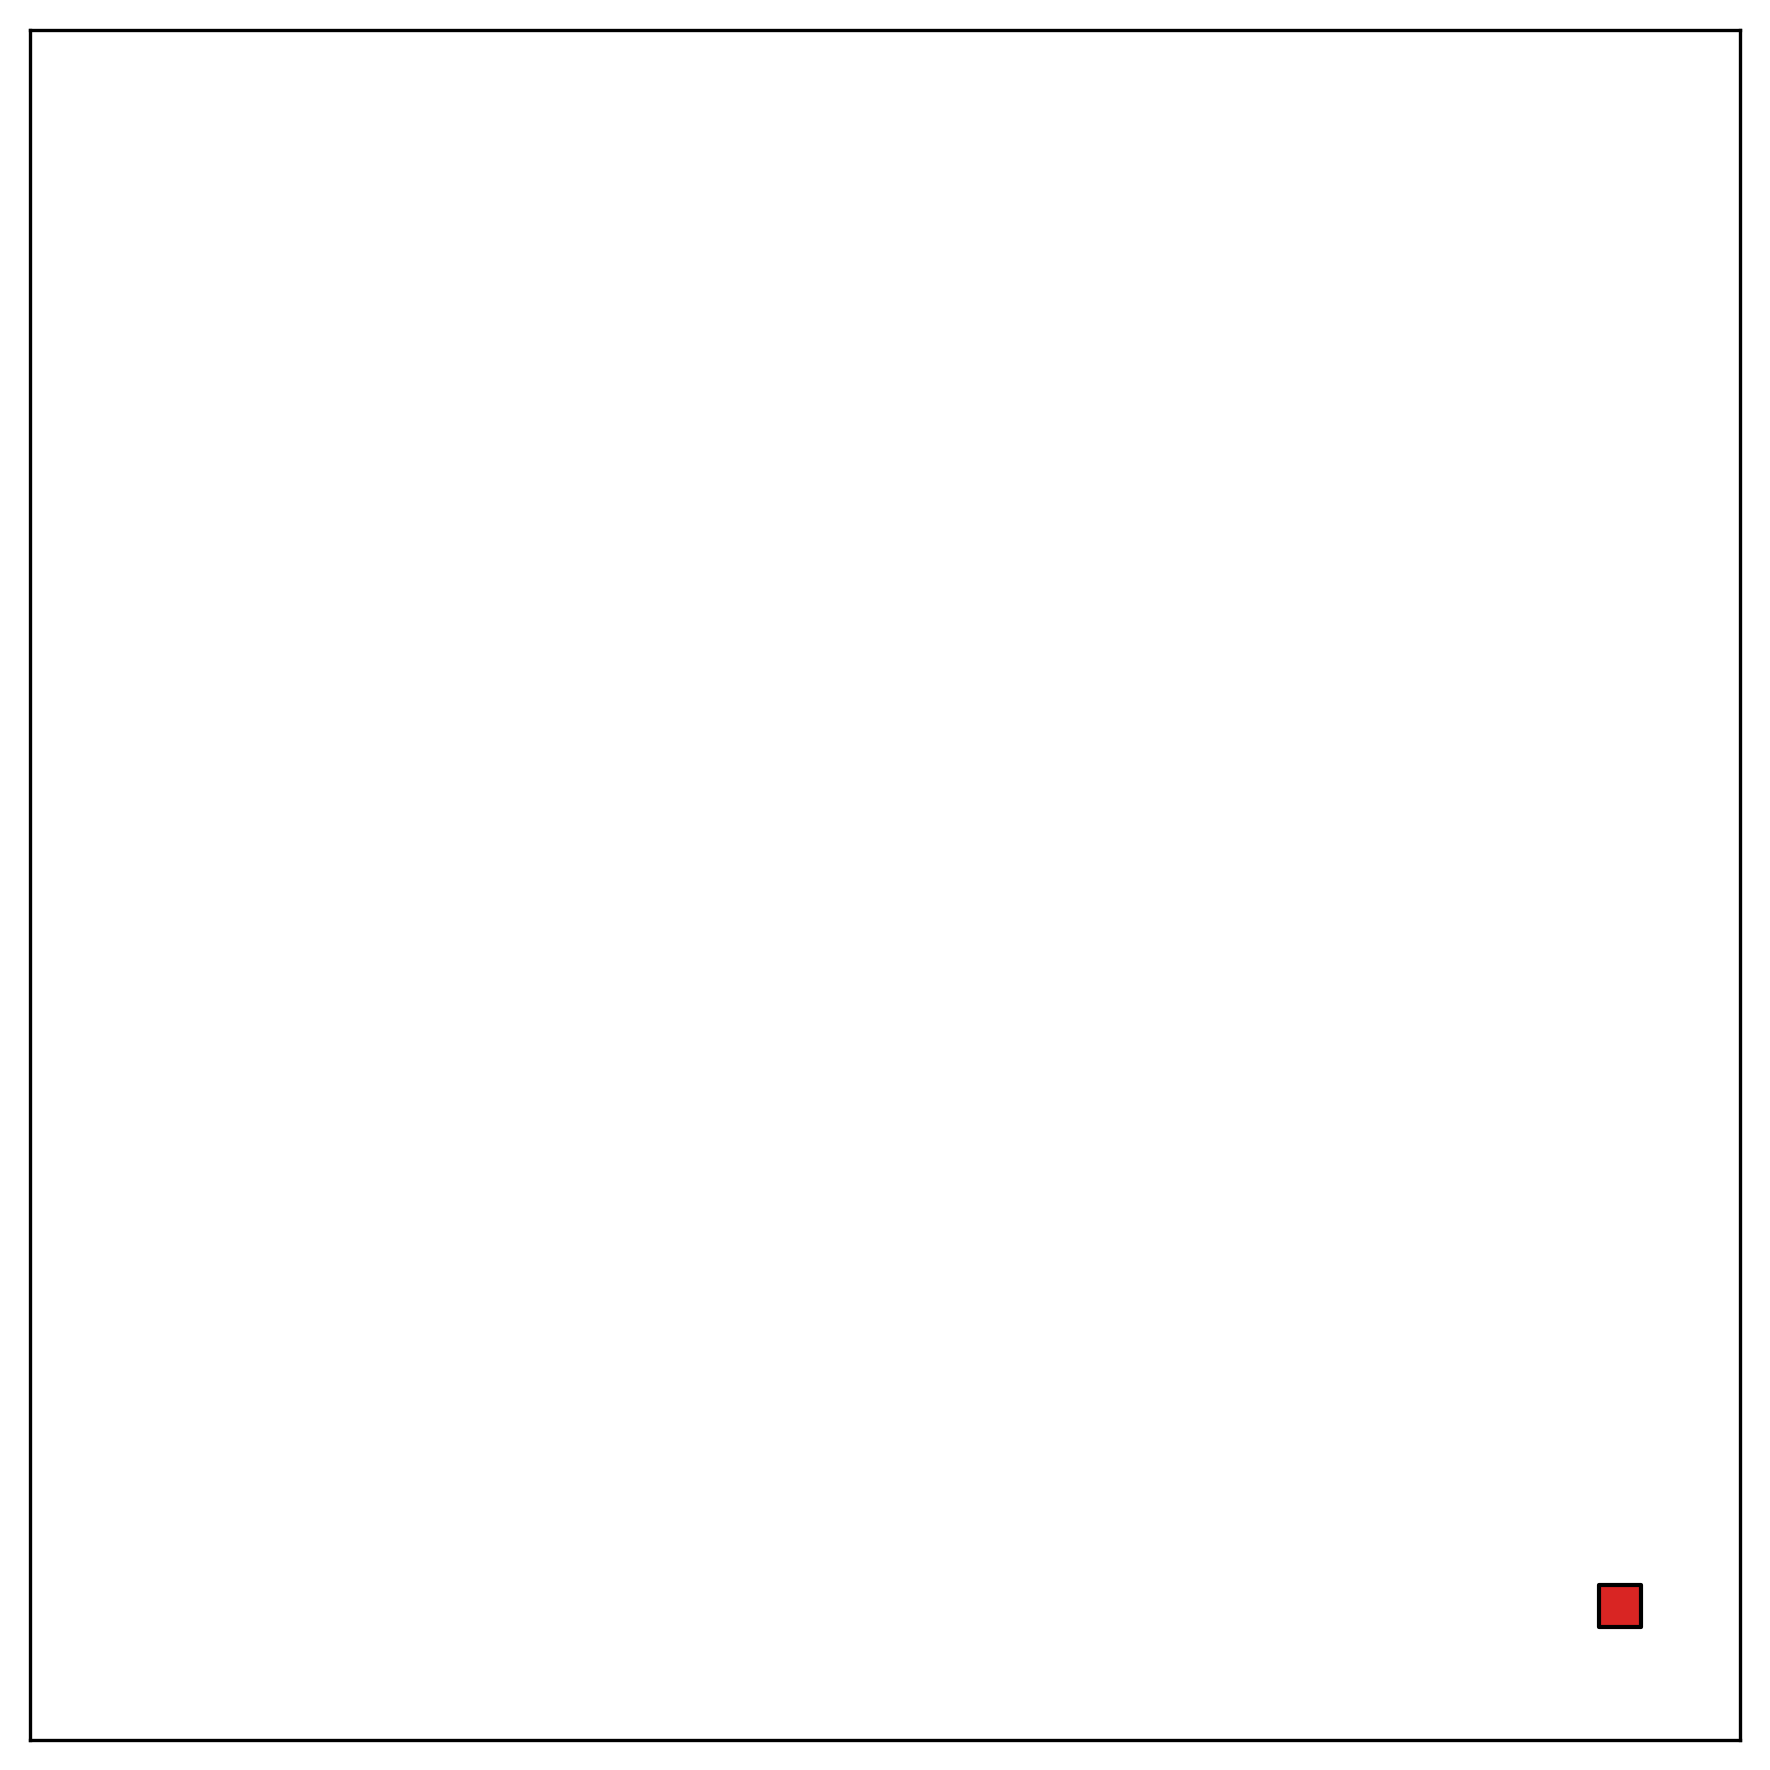

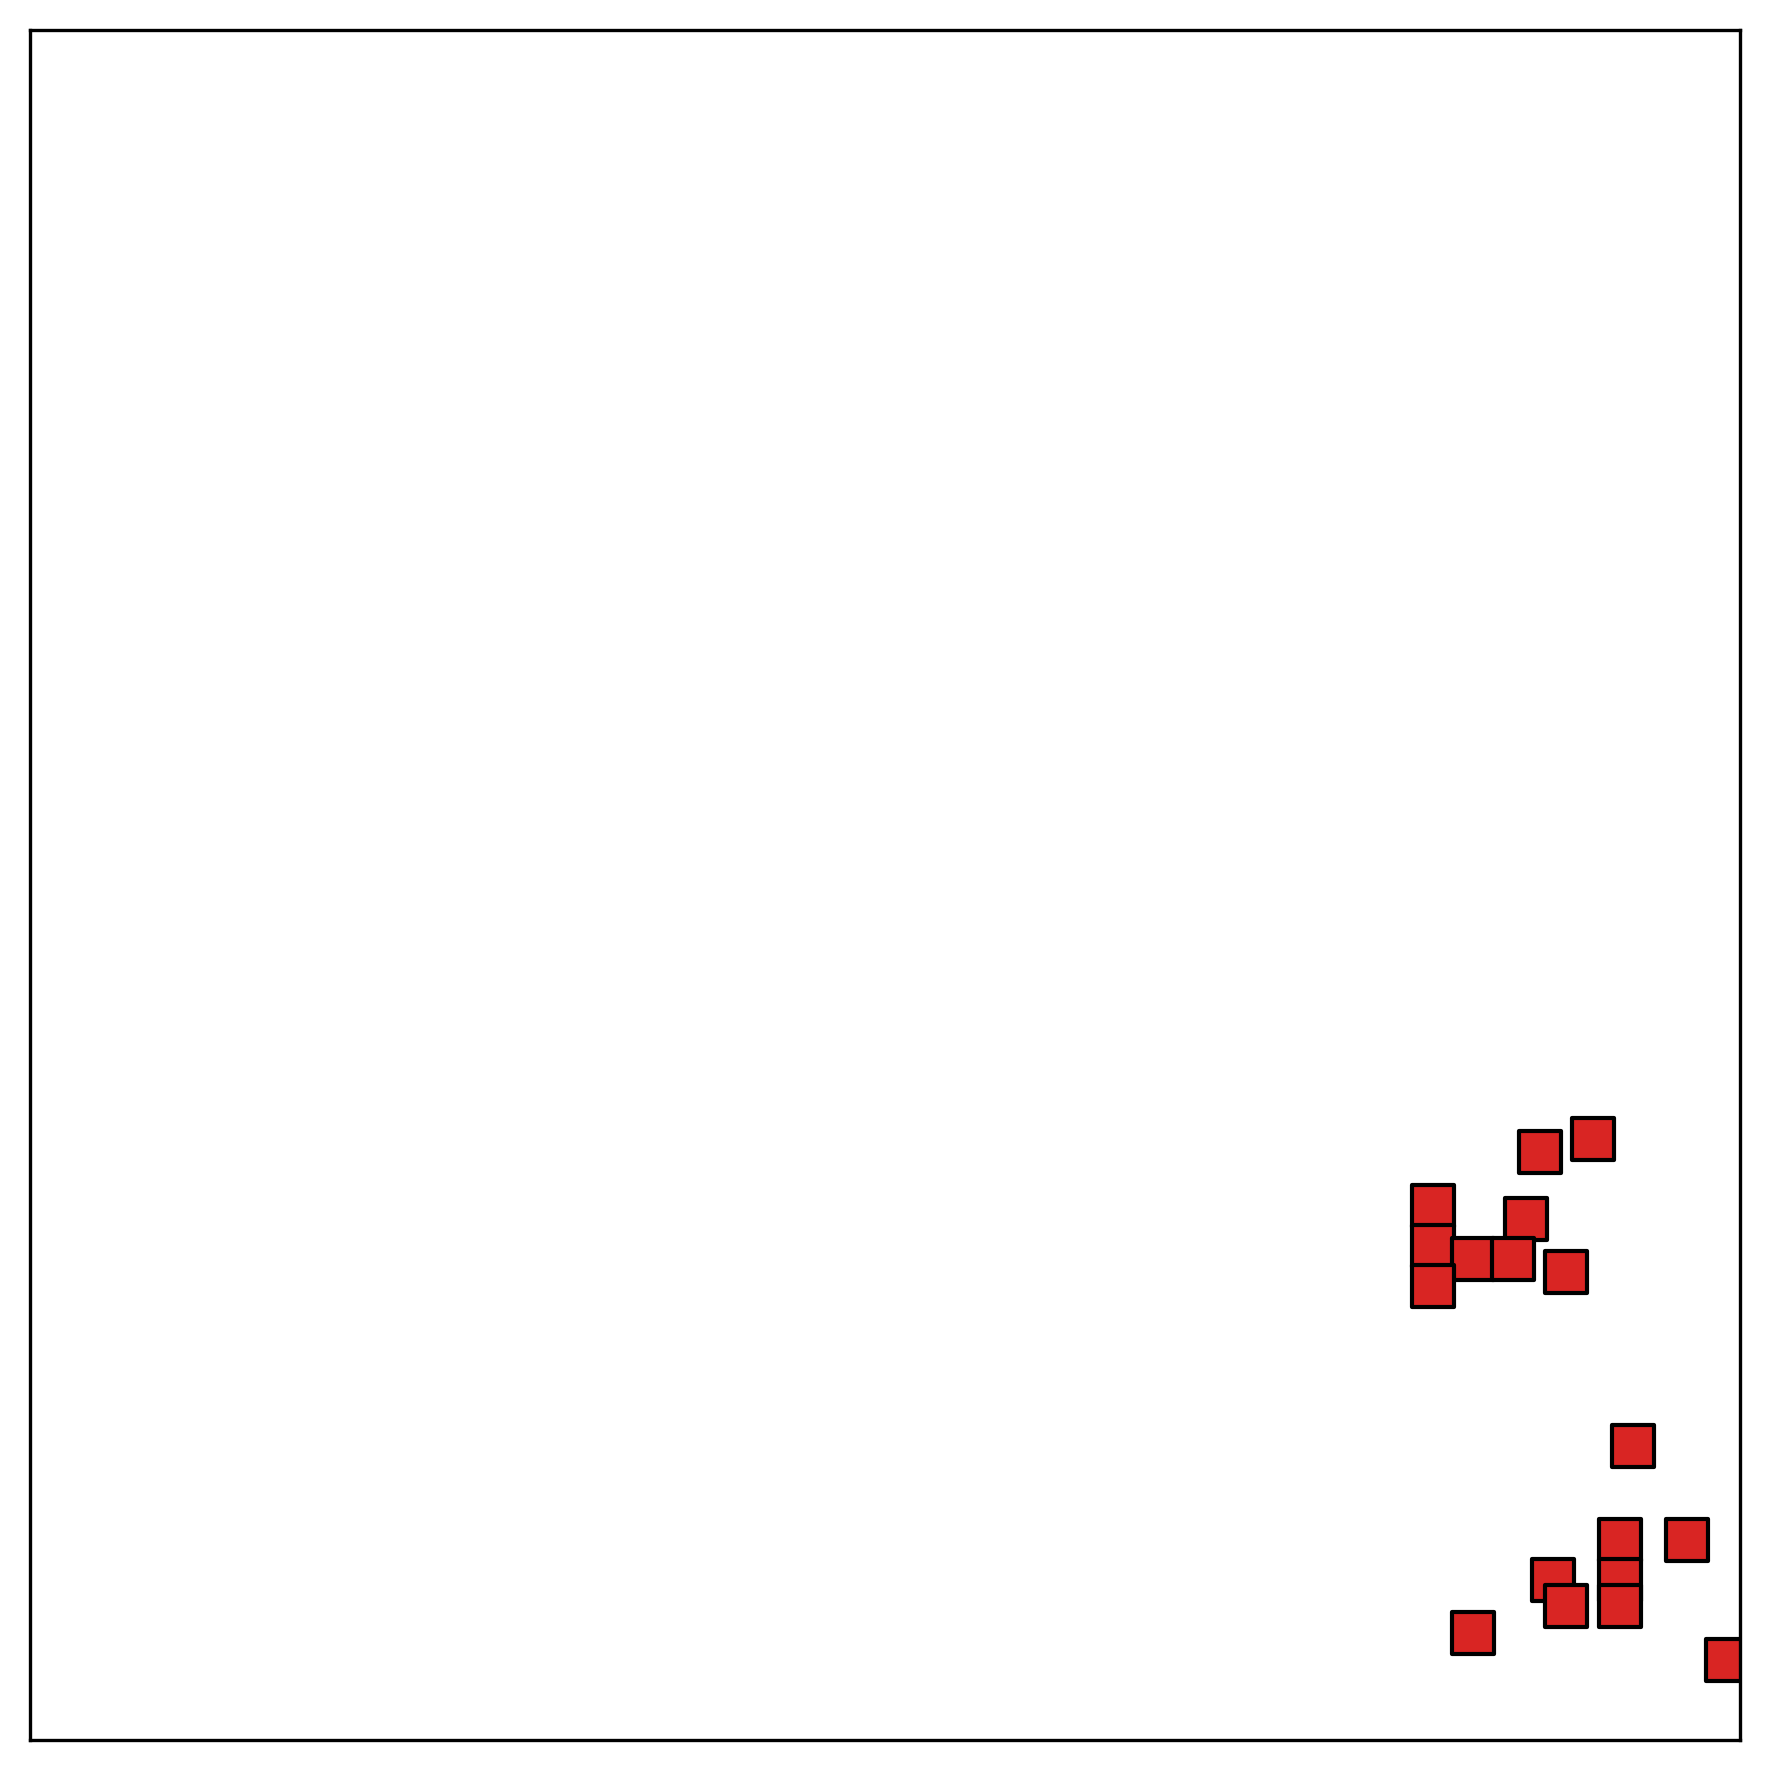

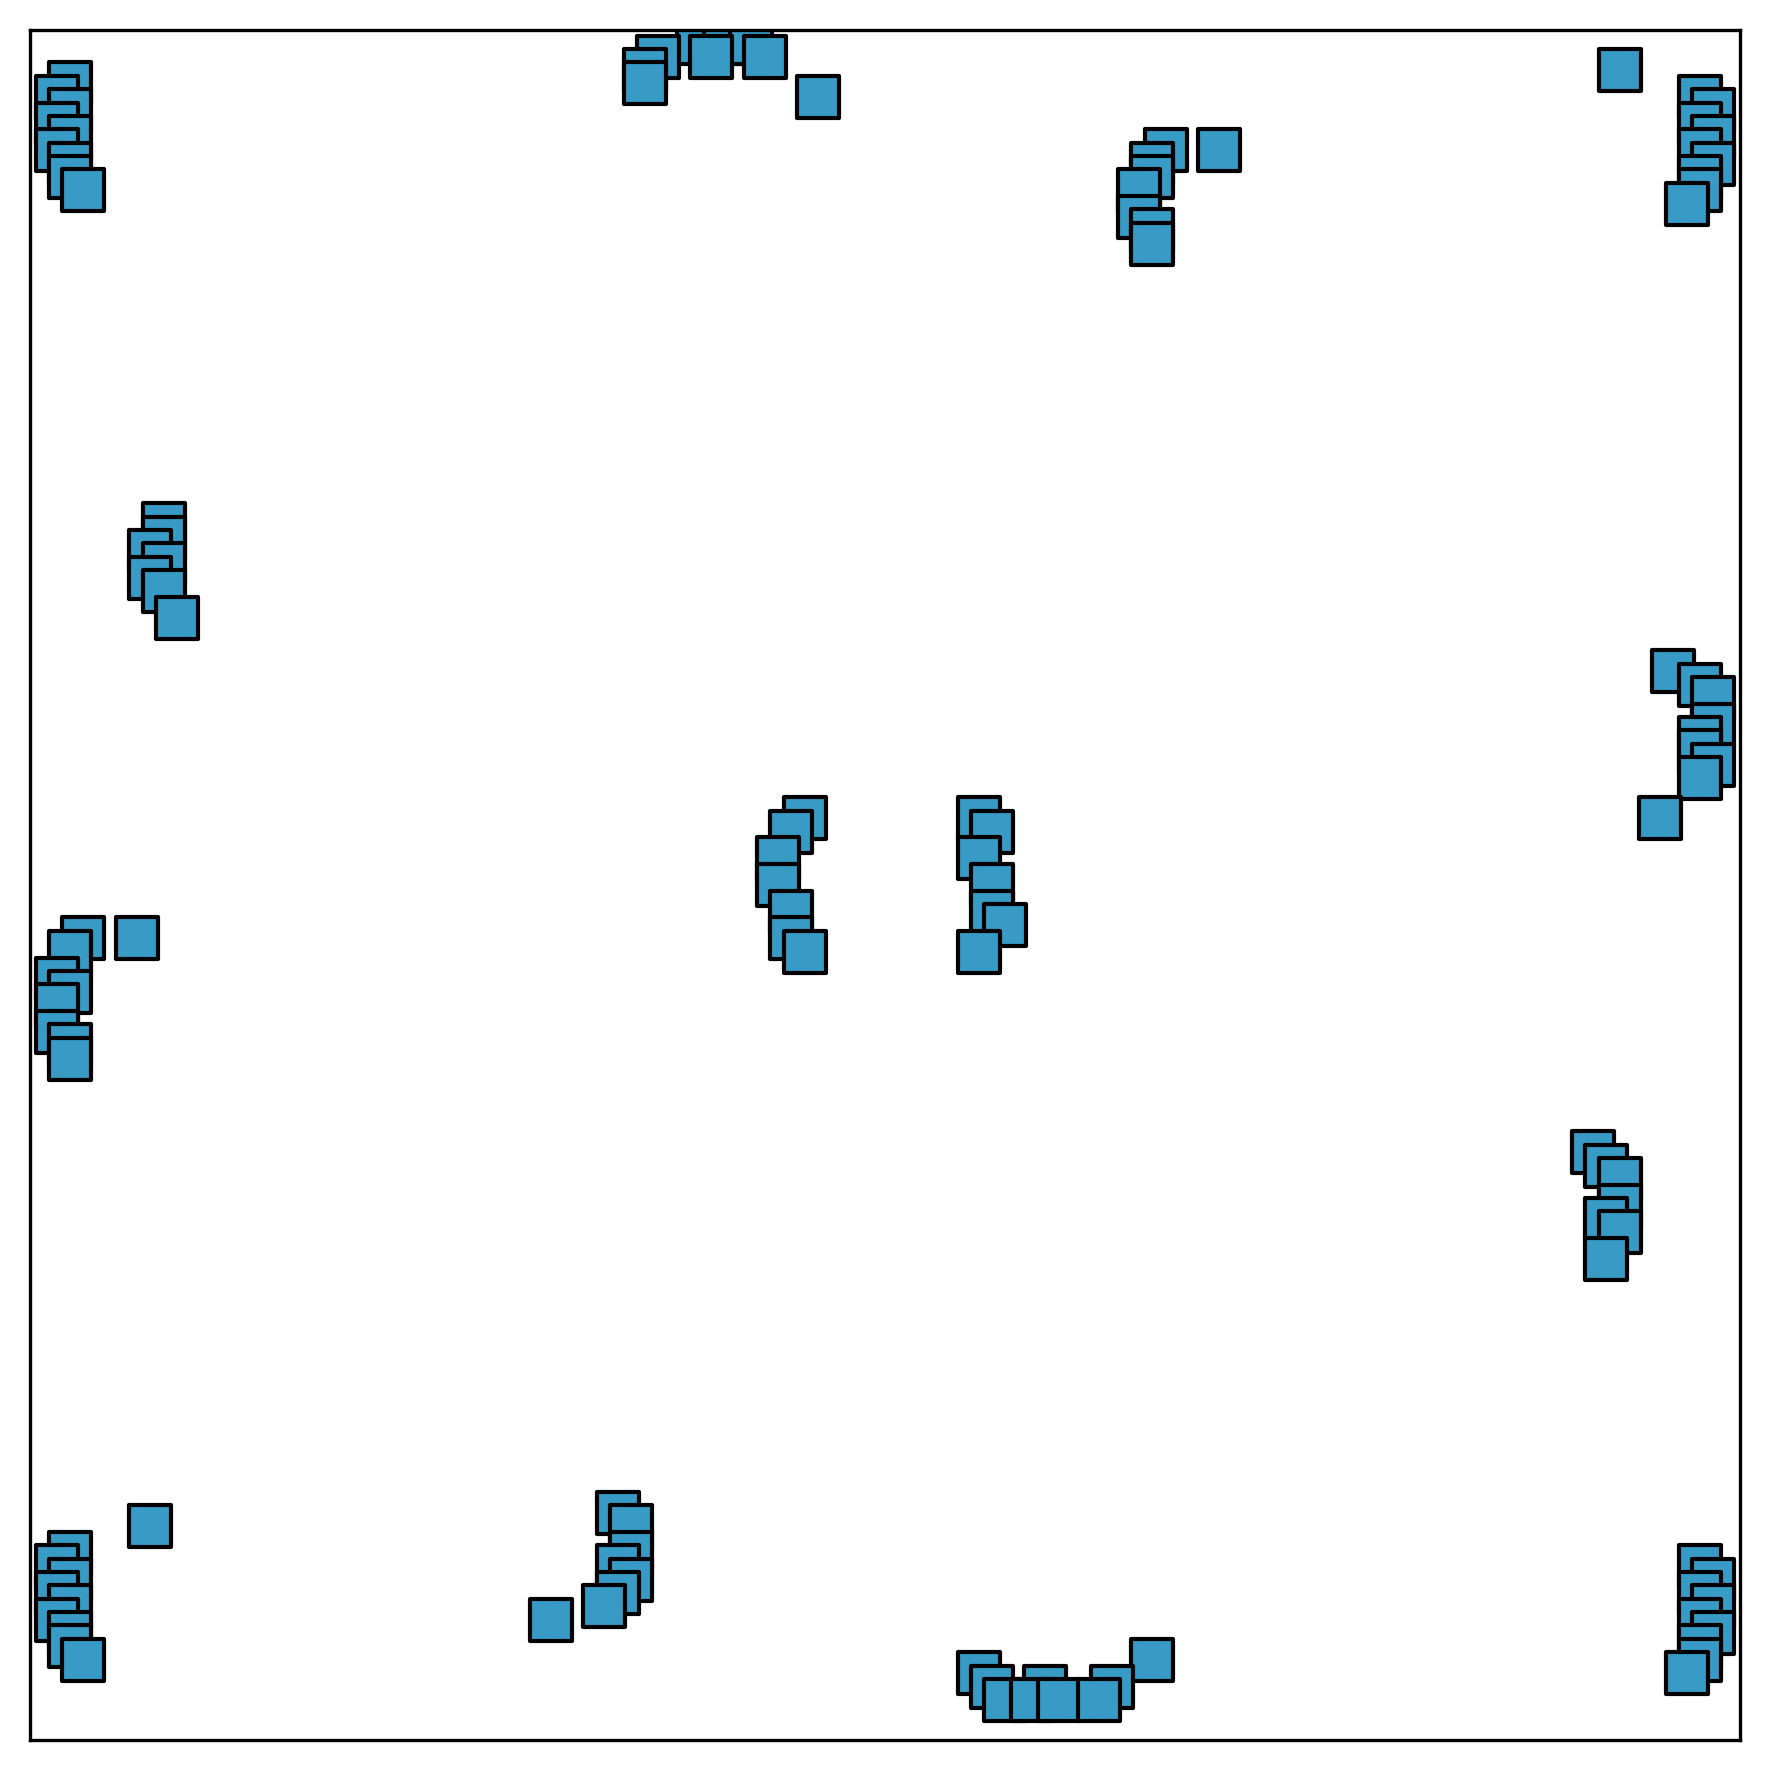

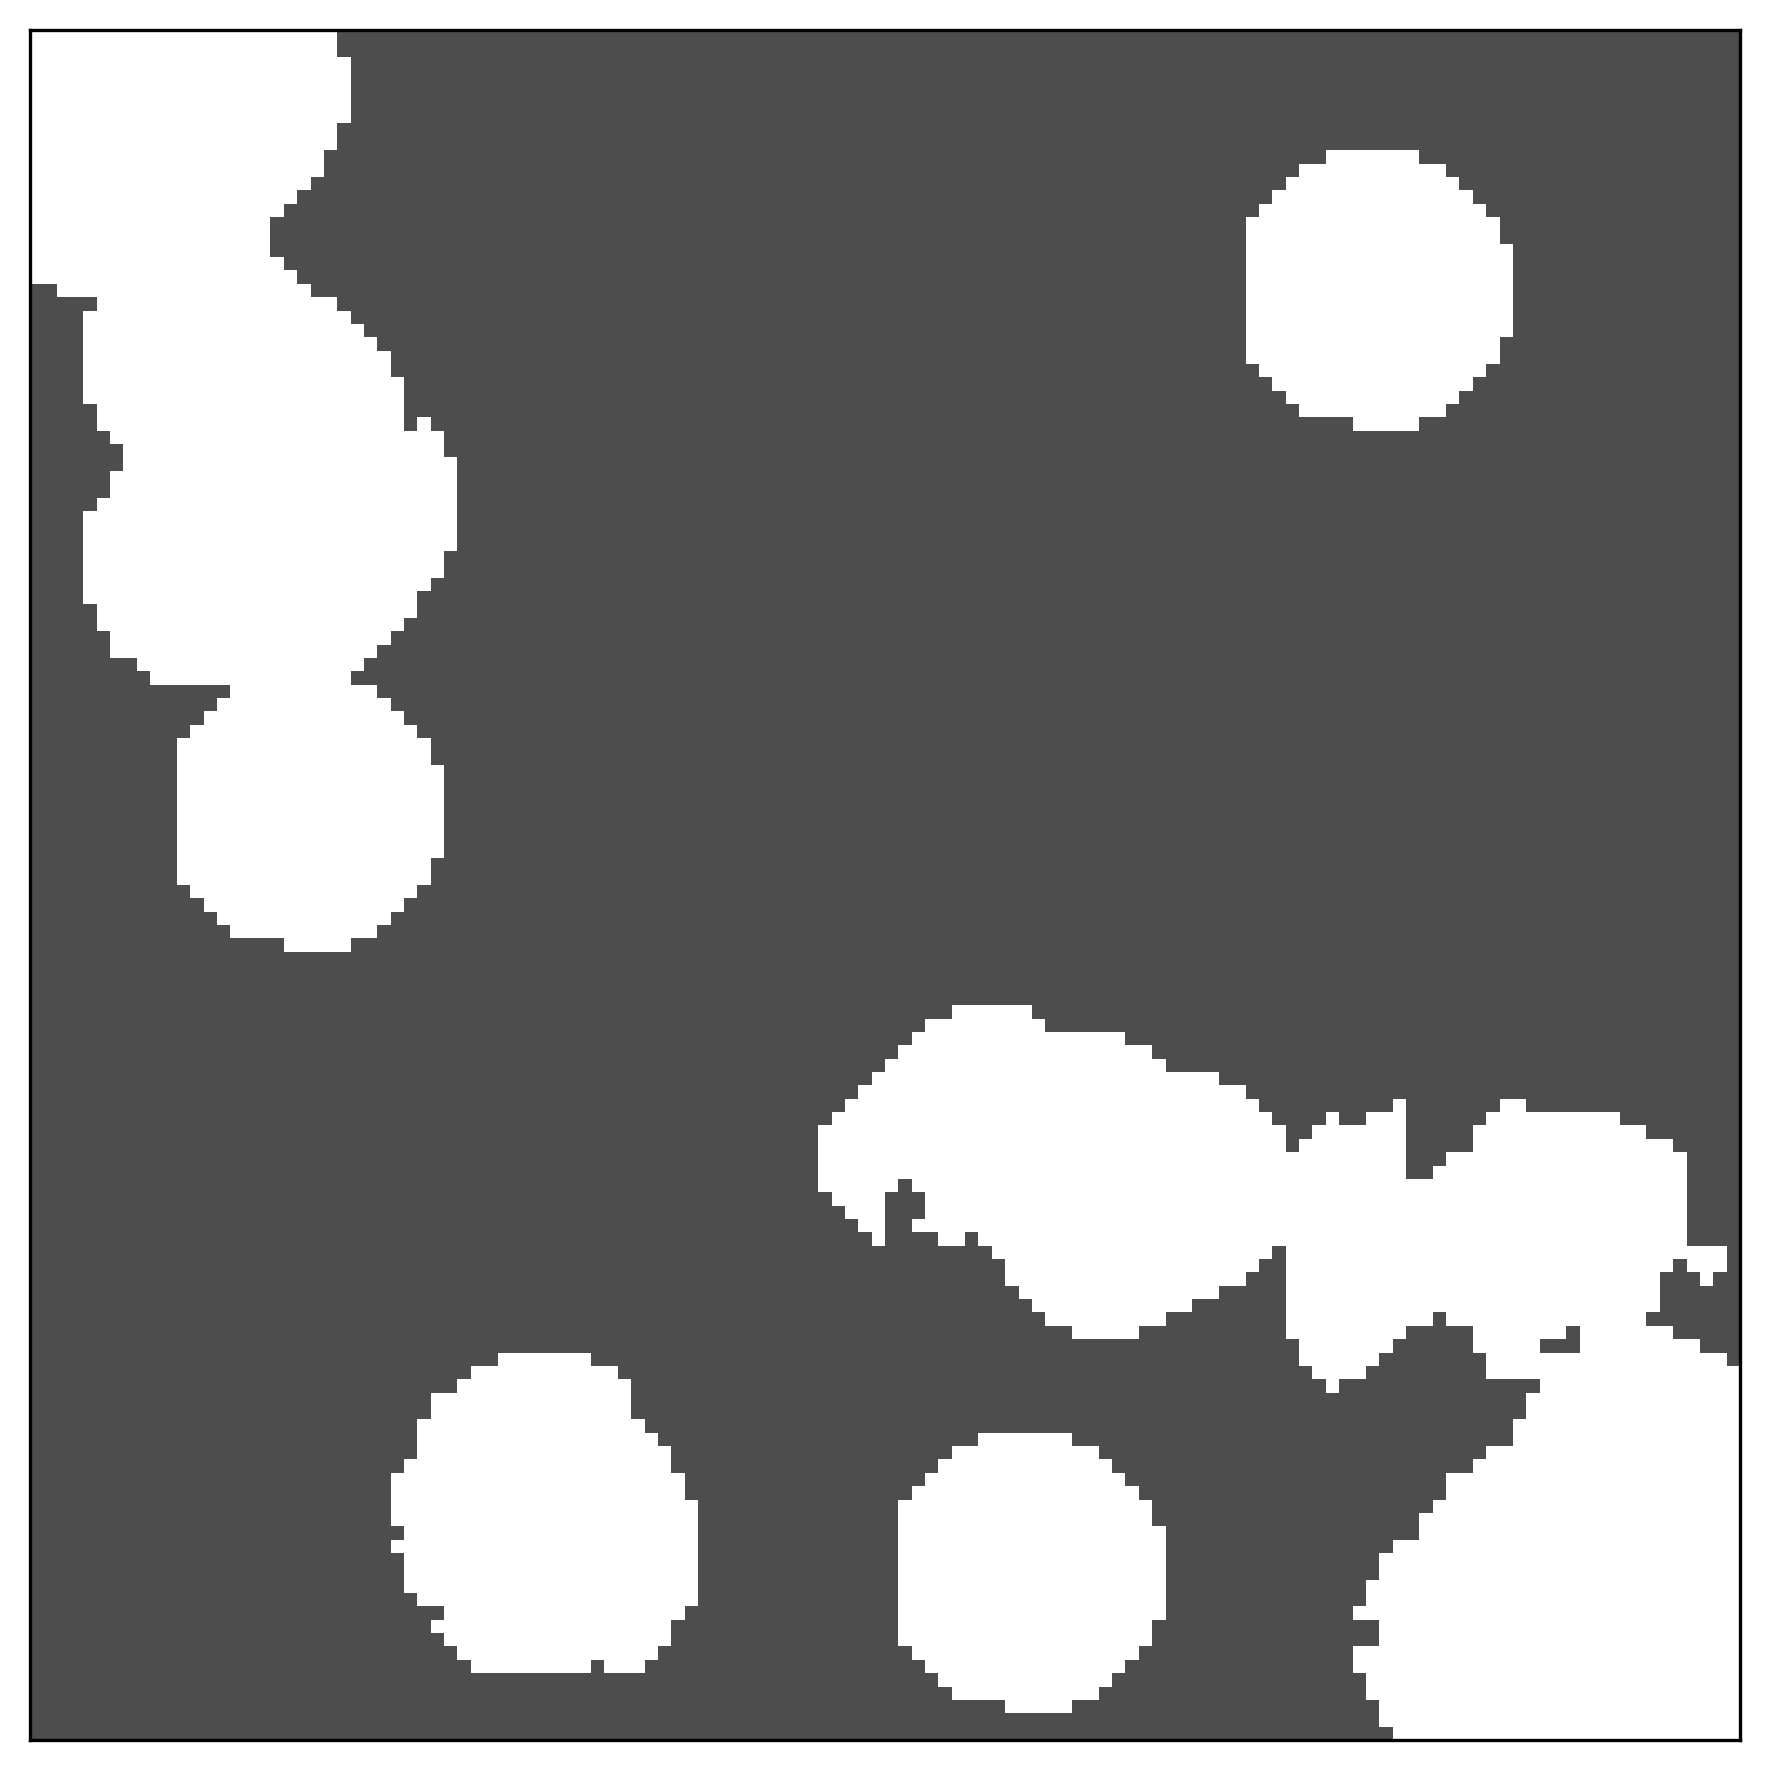

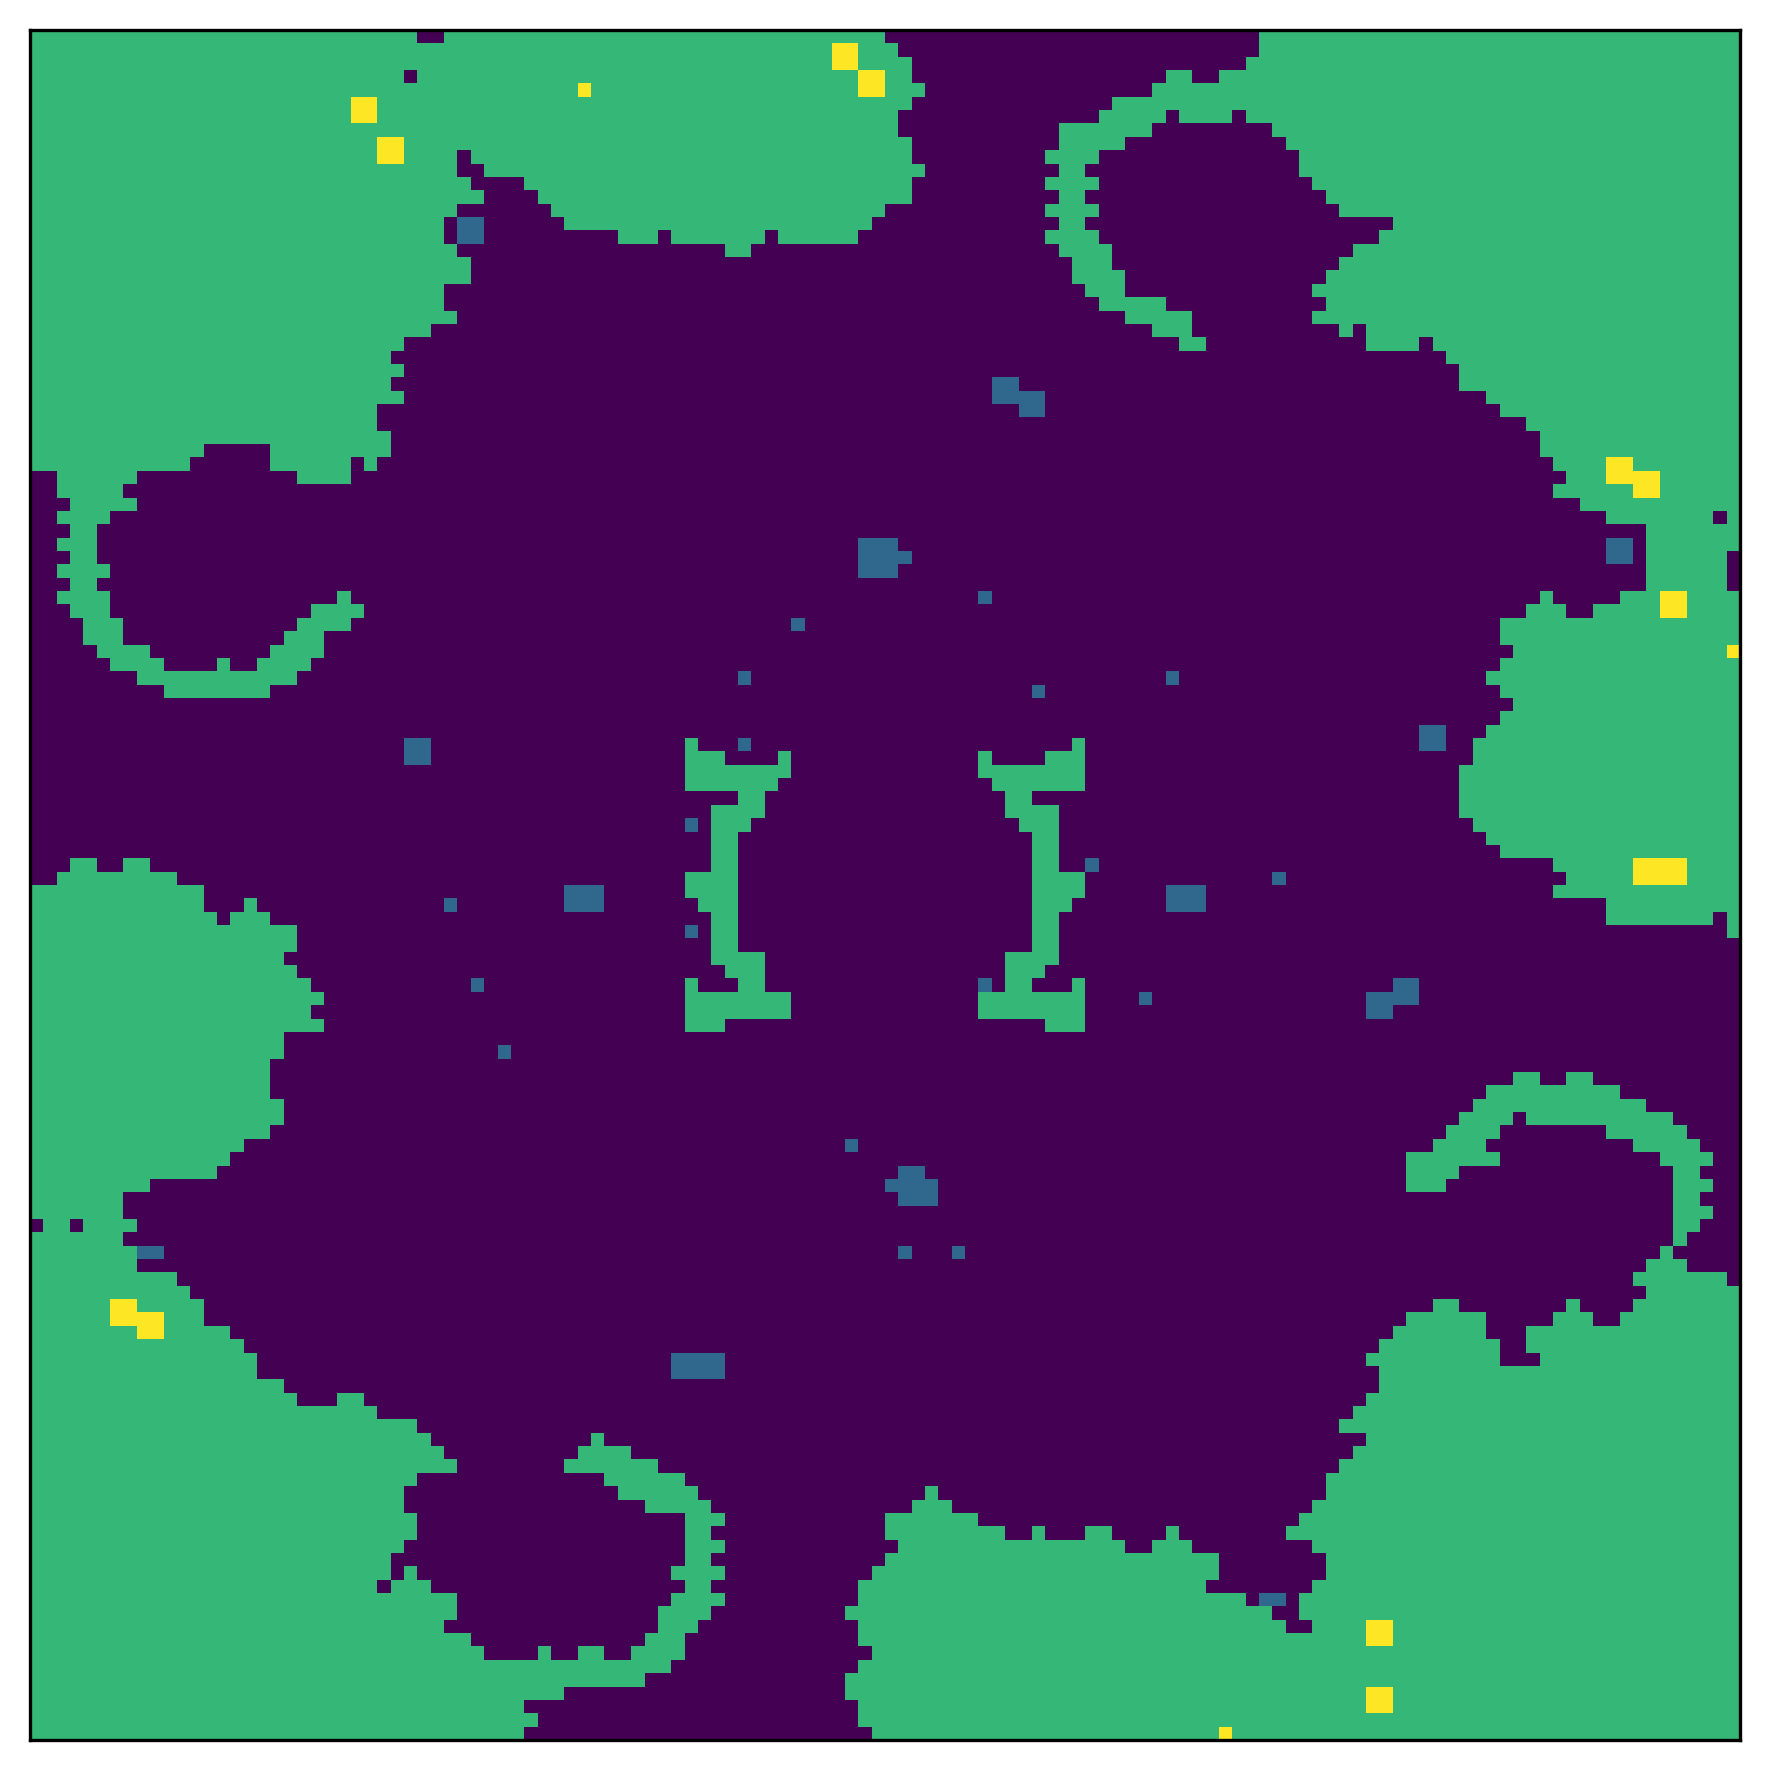

In [104]:
draw_channel(data, rep_name, frame)

In [ ]:
draw_overview(data, rep_name, frame)

In [106]:
vision_raw = data[Channel.Vision.value]

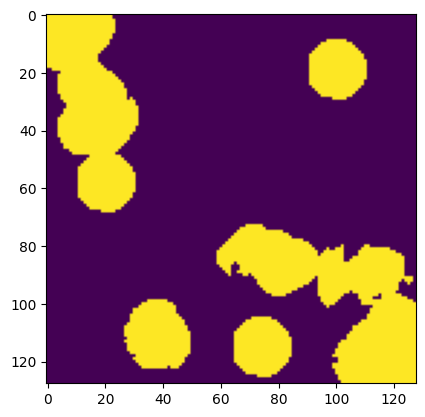

In [107]:
plt.imshow(vision_raw)

---
## 📌 Section: ground_truth_viewer.ipynb


---
## 📌 Section: rle-example-figure.ipynb


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

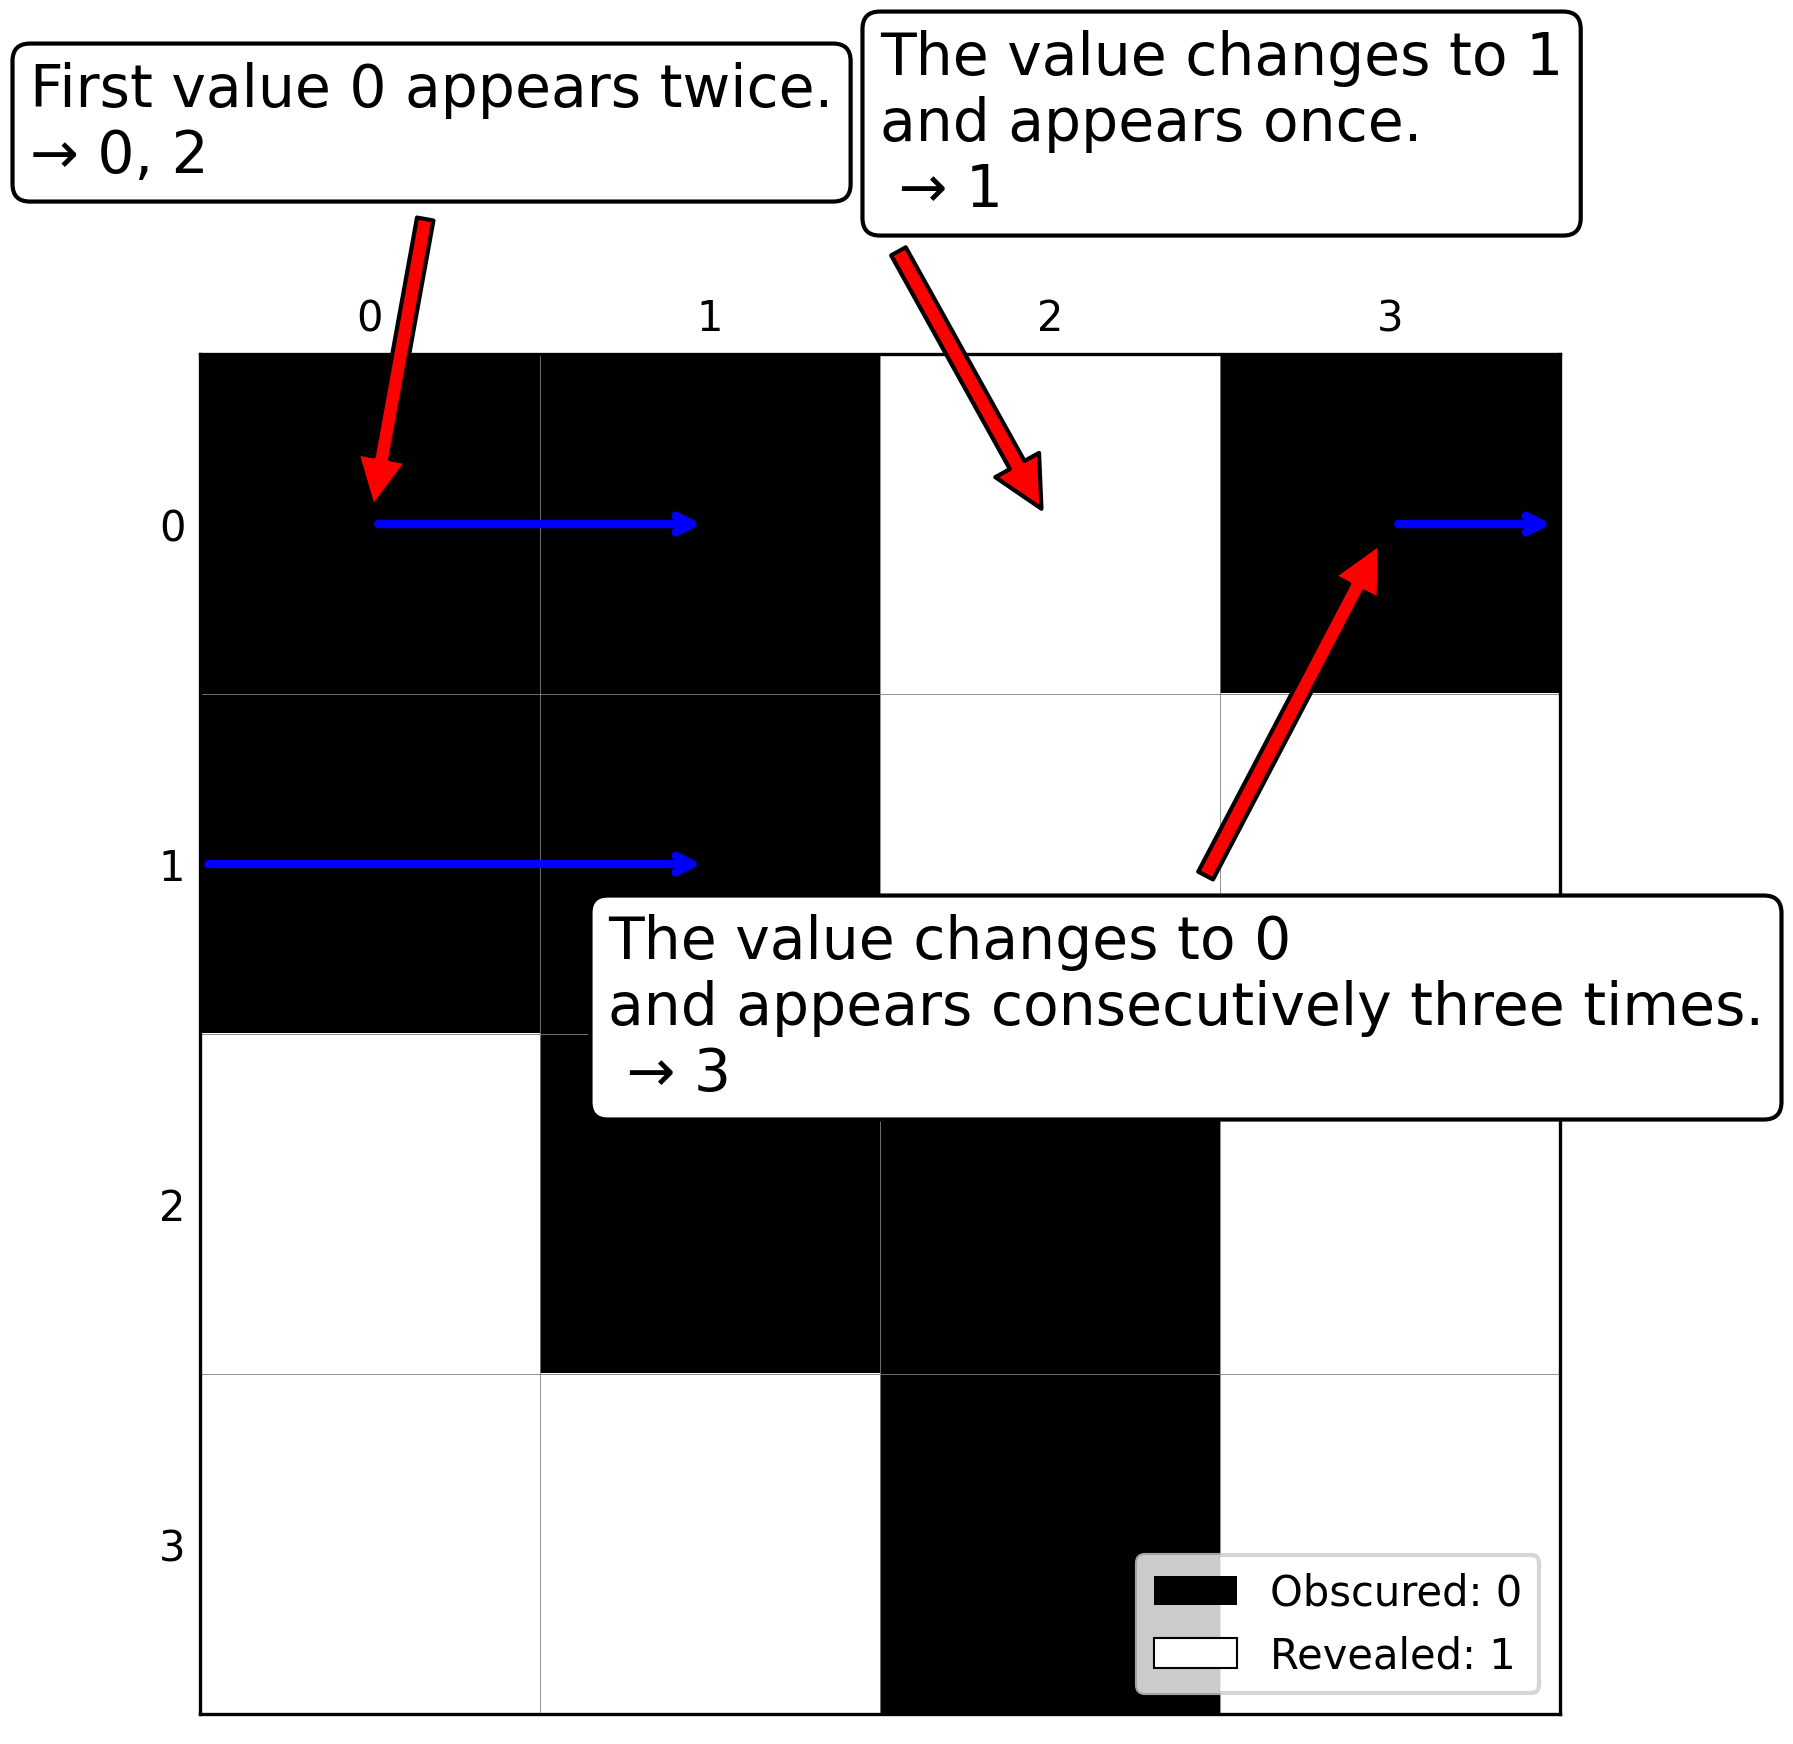

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 데이터 배열
array = np.array([[0, 0, 1, 0], 
                  [0, 0, 1, 1], 
                  [1, 0, 0, 1], 
                  [1, 1, 0, 1]])

# Figure 및 Axes 생성
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# 이미지 표시
ax.imshow(array, cmap='gray')

# 그리드 설정
ax.set_xticks(np.arange(-0.5, array.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, array.shape[0], 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.2)
ax.tick_params(which="both", size=0)  # 눈금 제거

# 색상 매핑
colors = {0: 'black', 1: 'white'}
cmap = plt.matplotlib.colors.ListedColormap(colors.values())

# 범례 패치 추가
legend_patches = [
    patches.Patch(facecolor='black', edgecolor='black', label='Obscured: 0', linewidth=0.),
    patches.Patch(facecolor='white', edgecolor='black', label='Revealed: 1', linewidth=0.5)
]

# 범례 추가
plt.legend(handles=legend_patches, loc='lower right', ncol=1)

# 축 설정
ax.tick_params(axis='x', top=True, bottom=False)
ax.tick_params(axis='y', left=True, right=False)
ax.xaxis.set_label_position("top")
ax.xaxis.set_ticks_position("top")

ax.set_xticks([0, 1, 2, 3])
ax.set_yticks([0, 1, 2, 3])

annotate_fontsize = 14

# 주석(annotate) 추가
ax.annotate('First value 0 appears twice.\n→ 0, 2',
            size=annotate_fontsize,
            xy=(0, 0), xycoords='data',
            xytext=(-1.0, -1.0),
            arrowprops=dict(facecolor='red', shrink=0.05),
            horizontalalignment='left', verticalalignment='bottom',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

ax.annotate('The value changes to 1\nand appears once.\n → 1',
            size=annotate_fontsize,
            xy=(2, 0), xycoords='data',
            xytext=(1.5, -0.9),
            arrowprops=dict(facecolor='red', shrink=0.05),
            horizontalalignment='left', verticalalignment='bottom',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

ax.annotate('The value changes to 0\nand appears consecutively three times.\n → 3',
            size=annotate_fontsize,
            xy=(3, 0), xycoords='data',
            xytext=(0.7, 1.7),
            arrowprops=dict(facecolor='red', shrink=0.05),
            horizontalalignment='left', verticalalignment='bottom',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

ax.annotate('',
            xy=(1, 0), xycoords='data',  # 화살표의 끝 위치
            xytext=(0, 0), textcoords='data',  # 화살표의 시작 위치
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=2))

ax.annotate('',
            xy=(3.5, 0), xycoords='data',  # 오른쪽 바깥으로 이동
            xytext=(3, 0), textcoords='data',
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=2))

ax.annotate('',
            xy=(1, 1), xycoords='data',  # 왼쪽 바깥에서 들어오는 효과
            xytext=(-0.5, 1), textcoords='data',
            arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=2))

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig(f'encoding_process_example_{annotate_fontsize}pt.png')

plt.show()


<Figure size 640x480 with 0 Axes>

In [17]:
import zipfile

In [ ]:
with zipfile.ZipFile('C:/Users/bcm/workspace/Observer/results/12.rep.zip', 'r') as zip_ref:
    file_list = zip_ref.namelist()
    
    for file in file_list:
        with zip_ref.open(file) as my_file:
            print(my_file.read())

---
## 📌 Section: rle_statistics.ipynb


In [19]:
import os
import glob

from enum import Enum, auto

import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [16]:
def run_length_encoding(arr):
    """Run-length encoding for a 1D numpy array."""
    """ return [(val, count), ...] """
    if arr.size == 0:
        return np.array([], dtype=int)
    
    n = arr.size
    rle = []
    count = 1
    for i in range(1, n):
        if arr[i] == arr[i - 1]:
            count += 1
        else:
            rle.append((arr[i - 1], count))
            count = 1
    rle.append((arr[-1], count))  # 마지막 값 추가
    return np.array(rle, dtype=int)


def custom_run_length_encoding(arr):
    """Custom run-length encoding for a 1D numpy array."""
    """ return first value, [count, ...] """
    if arr.size == 0:
        return np.array([], dtype=int)
    
    n = arr.size
    rle = []
    count = 1
    
    first_value = arr[0]
    for i in range(1, n):
        if arr[i] == arr[i - 1]:
            count += 1
        else:
            rle.append(count)
            count = 1
    rle.append(count)  # 마지막 값 추가

    return first_value.item(), np.array(rle, dtype=int)


# rle_vision = run_length_encoding(vision_raw.flatten())
# custom_rle_vision = custom_run_length_encoding(vision_raw.flatten())

In [17]:
def storage_size_comparison_single(rep, idx, vision_raw):
    """
    단일 프레임의 저장 크기를 계산.
    rep, idx 메타데이터와 함께 반환.
    """
    raw_int32 = vision_raw.astype(np.int32)
    raw_uint8 = vision_raw.astype(np.uint8)
    raw_bool = vision_raw.astype(bool)

    sizes = {
        "int32": raw_int32.nbytes,
        "uint8": raw_uint8.nbytes,
        "bool": raw_bool.nbytes,
    }

    flat_bool = raw_bool.flatten().astype(np.uint8)
    rle_vision = run_length_encoding(flat_bool)
    first_val, custom_rle = custom_run_length_encoding(flat_bool)

    rle_size = rle_vision.nbytes
    custom_rle_size = custom_rle.nbytes + np.array([first_val], dtype=custom_rle.dtype).nbytes

    return [rep, idx, sizes["int32"], sizes["uint8"], sizes["bool"], rle_size, custom_rle_size]

In [18]:
def storage_size_statistics(vision_frames):
    """
    모든 프레임에 대해 storage_size_comparison_single을 호출하고
    (rep, idx) 정보와 함께 DataFrame 반환 및 통계 계산.
    """
    results = []
    for rep, idx, vision_frame in vision_frames:
        results.append(storage_size_comparison_single(rep, idx, vision_frame))

    df = pd.DataFrame(results, columns=["rep", "idx", "int32", "uint8", "bool", "RLE", "Custom_RLE"])
    stats = df.describe(numeric_only=True)  # 통계: 숫자 컬럼만
    return df, stats

In [3]:
ex_visions = glob.glob("data/input/src/*/vision")

indexes = {}
for ex_vision in ex_visions:
    df = pd.read_csv(ex_vision, header=None, index_col=0)
    indexes.update({ex_vision.split(os.path.sep)[-2]: df.index.tolist()})

In [21]:
dst_dir = "data/input/dst/"
# npys = glob.glob(os.path.join(dst_dir, "*.npy"))

In [91]:
stats = []
for rep, frames in indexes.items():
    print(f"Processing {rep} with {len(frames)} frames...")
    for frame in tqdm.tqdm(frames):
        if not os.path.exists(os.path.join(dst_dir, rep, f"{frame}.npy")):
            print(f"File {os.path.join(dst_dir, rep, f'{frame}.npy')} does not exist. Skipping.")
            continue
        vision_raw = np.load(os.path.join(dst_dir, rep, f"{frame}.npy"))[Channel.Vision.value]
        stats.append(storage_size_comparison_single(rep, frame, vision_raw))  
    

Processing 438.rep with 11217 frames...


100%|██████████| 11217/11217 [02:19<00:00, 80.59it/s]


File data/input/dst/438.rep/29992.npy does not exist. Skipping.
File data/input/dst/438.rep/29996.npy does not exist. Skipping.
File data/input/dst/438.rep/29999.npy does not exist. Skipping.
File data/input/dst/438.rep/30000.npy does not exist. Skipping.
File data/input/dst/438.rep/30001.npy does not exist. Skipping.
File data/input/dst/438.rep/30002.npy does not exist. Skipping.
File data/input/dst/438.rep/30003.npy does not exist. Skipping.
File data/input/dst/438.rep/30004.npy does not exist. Skipping.
File data/input/dst/438.rep/30005.npy does not exist. Skipping.
File data/input/dst/438.rep/30007.npy does not exist. Skipping.
File data/input/dst/438.rep/30008.npy does not exist. Skipping.
File data/input/dst/438.rep/30009.npy does not exist. Skipping.
File data/input/dst/438.rep/30013.npy does not exist. Skipping.
File data/input/dst/438.rep/30016.npy does not exist. Skipping.
File data/input/dst/438.rep/30017.npy does not exist. Skipping.
File data/input/dst/438.rep/30019.npy do

100%|██████████| 14239/14239 [02:54<00:00, 81.49it/s]


File data/input/dst/36.rep/28330.npy does not exist. Skipping.
Processing 212.rep with 14074 frames...


...

File data/input/dst/212.rep/28252.npy does not exist. Skipping.
Processing 1660.rep with 15768 frames...


100%|██████████| 15768/15768 [02:48<00:00, 93.77it/s]


File data/input/dst/1660.rep/26122.npy does not exist. Skipping.
File data/input/dst/1660.rep/26124.npy does not exist. Skipping.
File data/input/dst/1660.rep/26126.npy does not exist. Skipping.
File data/input/dst/1660.rep/26128.npy does not exist. Skipping.
File data/input/dst/1660.rep/26129.npy does not exist. Skipping.
File data/input/dst/1660.rep/26130.npy does not exist. Skipping.
File data/input/dst/1660.rep/26131.npy does not exist. Skipping.
File data/input/dst/1660.rep/26133.npy does not exist. Skipping.
File data/input/dst/1660.rep/26134.npy does not exist. Skipping.
File data/input/dst/1660.rep/26135.npy does not exist. Skipping.
File data/input/dst/1660.rep/26136.npy does not exist. Skipping.
File data/input/dst/1660.rep/26140.npy does not exist. Skipping.
File data/input/dst/1660.rep/26141.npy does not exist. Skipping.
File data/input/dst/1660.rep/26142.npy does not exist. Skipping.
File data/input/dst/1660.rep/26143.npy does not exist. Skipping.
File data/input/dst/1660.

100%|██████████| 13971/13971 [02:46<00:00, 84.14it/s] 

File data/input/dst/522.rep/27884.npy does not exist. Skipping.
File data/input/dst/522.rep/27899.npy does not exist. Skipping.
File data/input/dst/522.rep/27918.npy does not exist. Skipping.
File data/input/dst/522.rep/27931.npy does not exist. Skipping.
File data/input/dst/522.rep/27935.npy does not exist. Skipping.
File data/input/dst/522.rep/27940.npy does not exist. Skipping.


In [93]:
df = pd.DataFrame(stats, columns=["rep", "idx", "int32", "uint8", "bool", "RLE", "Custom_RLE"])
# df.describe()['']  # 통계: 숫자 컬럼만

In [94]:
df['compression-ratio-RLE'] = df['RLE'] / df['bool']
df['compression-ratio-Custom_RLE'] = df['Custom_RLE'] / df['bool']

In [95]:
df

,rep,idx,int32,uint8,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
0,438.rep,34,65536,16384,16384,1344,680,0.082031,0.041504
1,438.rep,46,65536,16384,16384,1344,680,0.082031,0.041504
2,438.rep,54,65536,16384,16384,1328,672,0.081055,0.041016
3,438.rep,58,65536,16384,16384,1328,672,0.081055,0.041016
4,438.rep,73,65536,16384,16384,1328,672,0.081055,0.041016
...,...,...,...,...,...,...,...,...,...
67367,522.rep,27872,65536,16384,16384,8848,4432,0.540039,0.270508
67368,522.rep,27875,65536,16384,16384,8880,4448,0.541992,0.271484
67369,522.rep,27876,65536,16384,16384,8880,4448,0.541992,0.271484
67370,522.rep,27879,65536,16384,16384,8880,4448,0.541992,0.271484


In [121]:
newnew = df.describe()

In [123]:
newnew[['idx', 'int32', 'uint8', 'bool', 'RLE', 'Custom_RLE']] = newnew[['idx', 'int32', 'uint8', 'bool', 'RLE', 'Custom_RLE']].astype(int)

In [124]:
newnew

,idx,int32,uint8,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
count,67372,67372,67372,67372,67372,67372,67372.000000,67372.000000
mean,15706,65536,16384,16384,7263,3639,0.443329,0.222153
std,7463,0,0,0,2109,1054,0.128778,0.064389
min,26,65536,16384,16384,1328,672,0.081055,0.041016
25%,9715,65536,16384,16384,5584,2800,0.340820,0.170898
50%,16049,65536,16384,16384,7248,3632,0.442383,0.221680
75%,21940,65536,16384,16384,8912,4464,0.543945,0.272461
max,29988,65536,16384,16384,13680,6848,0.834961,0.417969


In [97]:
results = statistics[['bool', 'RLE', 'Custom_RLE', 'compression-ratio-RLE', 'compression-ratio-Custom_RLE']]

In [98]:
results

,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
count,67372.0,67372.000000,67372.000000,67372.000000,67372.000000
mean,16384.0,7263.507689,3639.753844,0.443329,0.222153
std,0.0,2109.891863,1054.945932,0.128778,0.064389
min,16384.0,1328.000000,672.000000,0.081055,0.041016
25%,16384.0,5584.000000,2800.000000,0.340820,0.170898
50%,16384.0,7248.000000,3632.000000,0.442383,0.221680
75%,16384.0,8912.000000,4464.000000,0.543945,0.272461
max,16384.0,13680.000000,6848.000000,0.834961,0.417969


In [99]:
results.columns = [
    'Raw vision data', 
    'Conventional RLE',
    'Custom RLE',
    'Compression ratio w/ Conventional RLE',
    'Compression ratio w/ Custom RLE'
    ]

In [100]:
results['Raw vision data'] = results['Raw vision data'].astype(np.int32)
results['Conventional RLE'] = results['Conventional RLE'].astype(np.int32)
results['Custom RLE'] = results['Custom RLE'].astype(np.int32)
results['Compression ratio w/ Conventional RLE'] = results['Compression ratio w/ Conventional RLE'].astype(np.float32)
results['Compression ratio w/ Custom RLE'] = results['Compression ratio w/ Custom RLE'].astype(np.float32)

/tmp/ipykernel_3513/1239349489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Raw vision data'] = results['Raw vision data'].astype(np.int32)
/tmp/ipykernel_3513/1239349489.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Conventional RLE'] = results['Conventional RLE'].astype(np.int32)
/tmp/ipykernel_3513/1239349489.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [101]:
results

,Raw vision data,Conventional RLE,Custom RLE,Compression ratio w/ Conventional RLE,Compression ratio w/ Custom RLE
count,67372,67372,67372,67372.000000,67372.000000
mean,16384,7263,3639,0.443329,0.222153
std,0,2109,1054,0.128778,0.064389
min,16384,1328,672,0.081055,0.041016
25%,16384,5584,2800,0.340820,0.170898
50%,16384,7248,3632,0.442383,0.221680
75%,16384,8912,4464,0.543945,0.272461
max,16384,13680,6848,0.834961,0.417969


In [102]:
res = results.transpose()[['mean', 'std']].transpose()
res['Raw vision data'] = res['Raw vision data'].astype(np.int32)
res['Conventional RLE'] = res['Conventional RLE'].astype(np.int32)
res['Custom RLE'] = res['Custom RLE'].astype(np.int32)

In [103]:
res

,Raw vision data,Conventional RLE,Custom RLE,Compression ratio w/ Conventional RLE,Compression ratio w/ Custom RLE
mean,16384,7263,3639,0.443329,0.222153
std,0,2109,1054,0.128778,0.064389


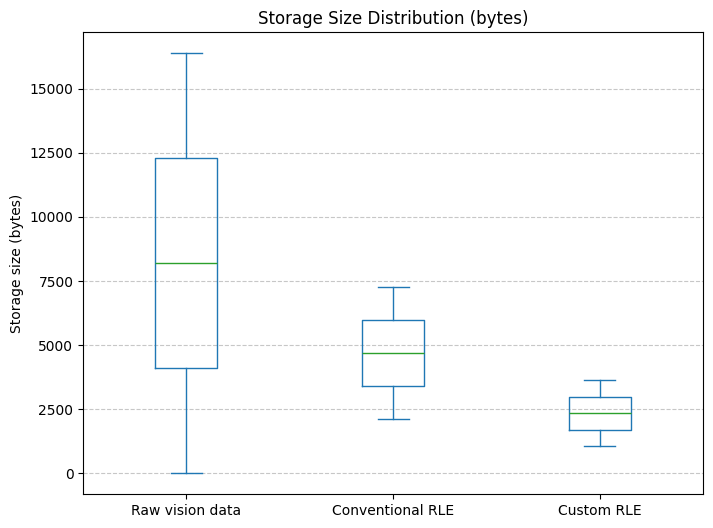

In [104]:
import matplotlib.pyplot as plt

# df가 위의 데이터를 포함하고 있다고 가정
columns = ['Raw vision data', 'Conventional RLE', 'Custom RLE']

# Boxplot 생성
res[columns].plot(kind='box', figsize=(8, 6), title='Storage Size Distribution (bytes)')

plt.ylabel('Storage size (bytes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [110]:
statistics

,idx,int32,uint8,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
count,67372.000000,67372.0,67372.0,67372.0,67372.000000,67372.000000,67372.000000,67372.000000
mean,15706.944294,65536.0,16384.0,16384.0,7263.507689,3639.753844,0.443329,0.222153
std,7463.991484,0.0,0.0,0.0,2109.891863,1054.945932,0.128778,0.064389
min,26.000000,65536.0,16384.0,16384.0,1328.000000,672.000000,0.081055,0.041016
25%,9715.000000,65536.0,16384.0,16384.0,5584.000000,2800.000000,0.340820,0.170898
50%,16049.000000,65536.0,16384.0,16384.0,7248.000000,3632.000000,0.442383,0.221680
75%,21940.000000,65536.0,16384.0,16384.0,8912.000000,4464.000000,0.543945,0.272461
max,29988.000000,65536.0,16384.0,16384.0,13680.000000,6848.000000,0.834961,0.417969


In [111]:
new_df = df[['bool', 'RLE', 'Custom_RLE', 'compression-ratio-RLE', 'compression-ratio-Custom_RLE']]

In [113]:
new_df.columns = [
    'Raw vision data', 
    'Conventional RLE',
    'Custom RLE',
    'Compression ratio w/ Conventional RLE',
    'Compression ratio w/ Custom RLE'
    ]

<Axes: title={'center': 'Storage Size Distribution (bytes)'}>

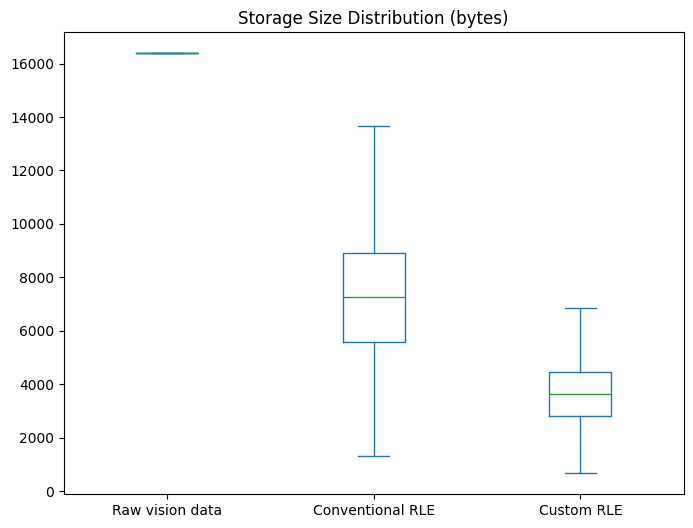

In [115]:
new_df[['Raw vision data', 
    'Conventional RLE',
    'Custom RLE']].plot(kind='box', figsize=(8, 6), title='Storage Size Distribution (bytes)')

<Axes: title={'center': 'Compression Ratio Distribution'}>

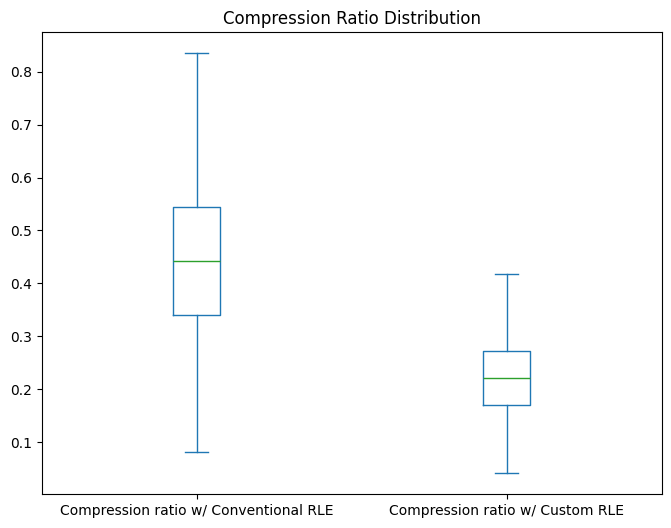

In [117]:
new_df[['Compression ratio w/ Conventional RLE',
    'Compression ratio w/ Custom RLE']].plot(kind='box', figsize=(8, 6), title='Compression Ratio Distribution')